<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Solver_for_Superconducting_Critical_Temperature_Prediction_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install cupy-cuda12x

Building adaptive spatial Usadel-adjacency model on the L4 GPU.
Auditing the reduced adjacency surrogate away from the nominal point.
Reduced-model audit passed: max |ΔTc| = 0.083 mK.
Running adaptive parallel Metropolis sampling on the GPU.


,Quantity,Value
0,Spatial reference Tc,1.185885 K
1,Reduced nominal Tc,1.185894 K
2,Reduced-model correction,-0.009 mK
3,Surrogate max audit |ΔTc|,0.083 mK
4,Metropolis mean Tc,1.189145 K
5,Metropolis median Tc,1.186210 K
6,Metropolis 68% interval,"[1.112512, 1.265095] K"
7,Metropolis 95% interval,"[1.044738, 1.346921] K"
8,Metropolis acceptance,0.299
9,Split Tc R-hat,1.0024


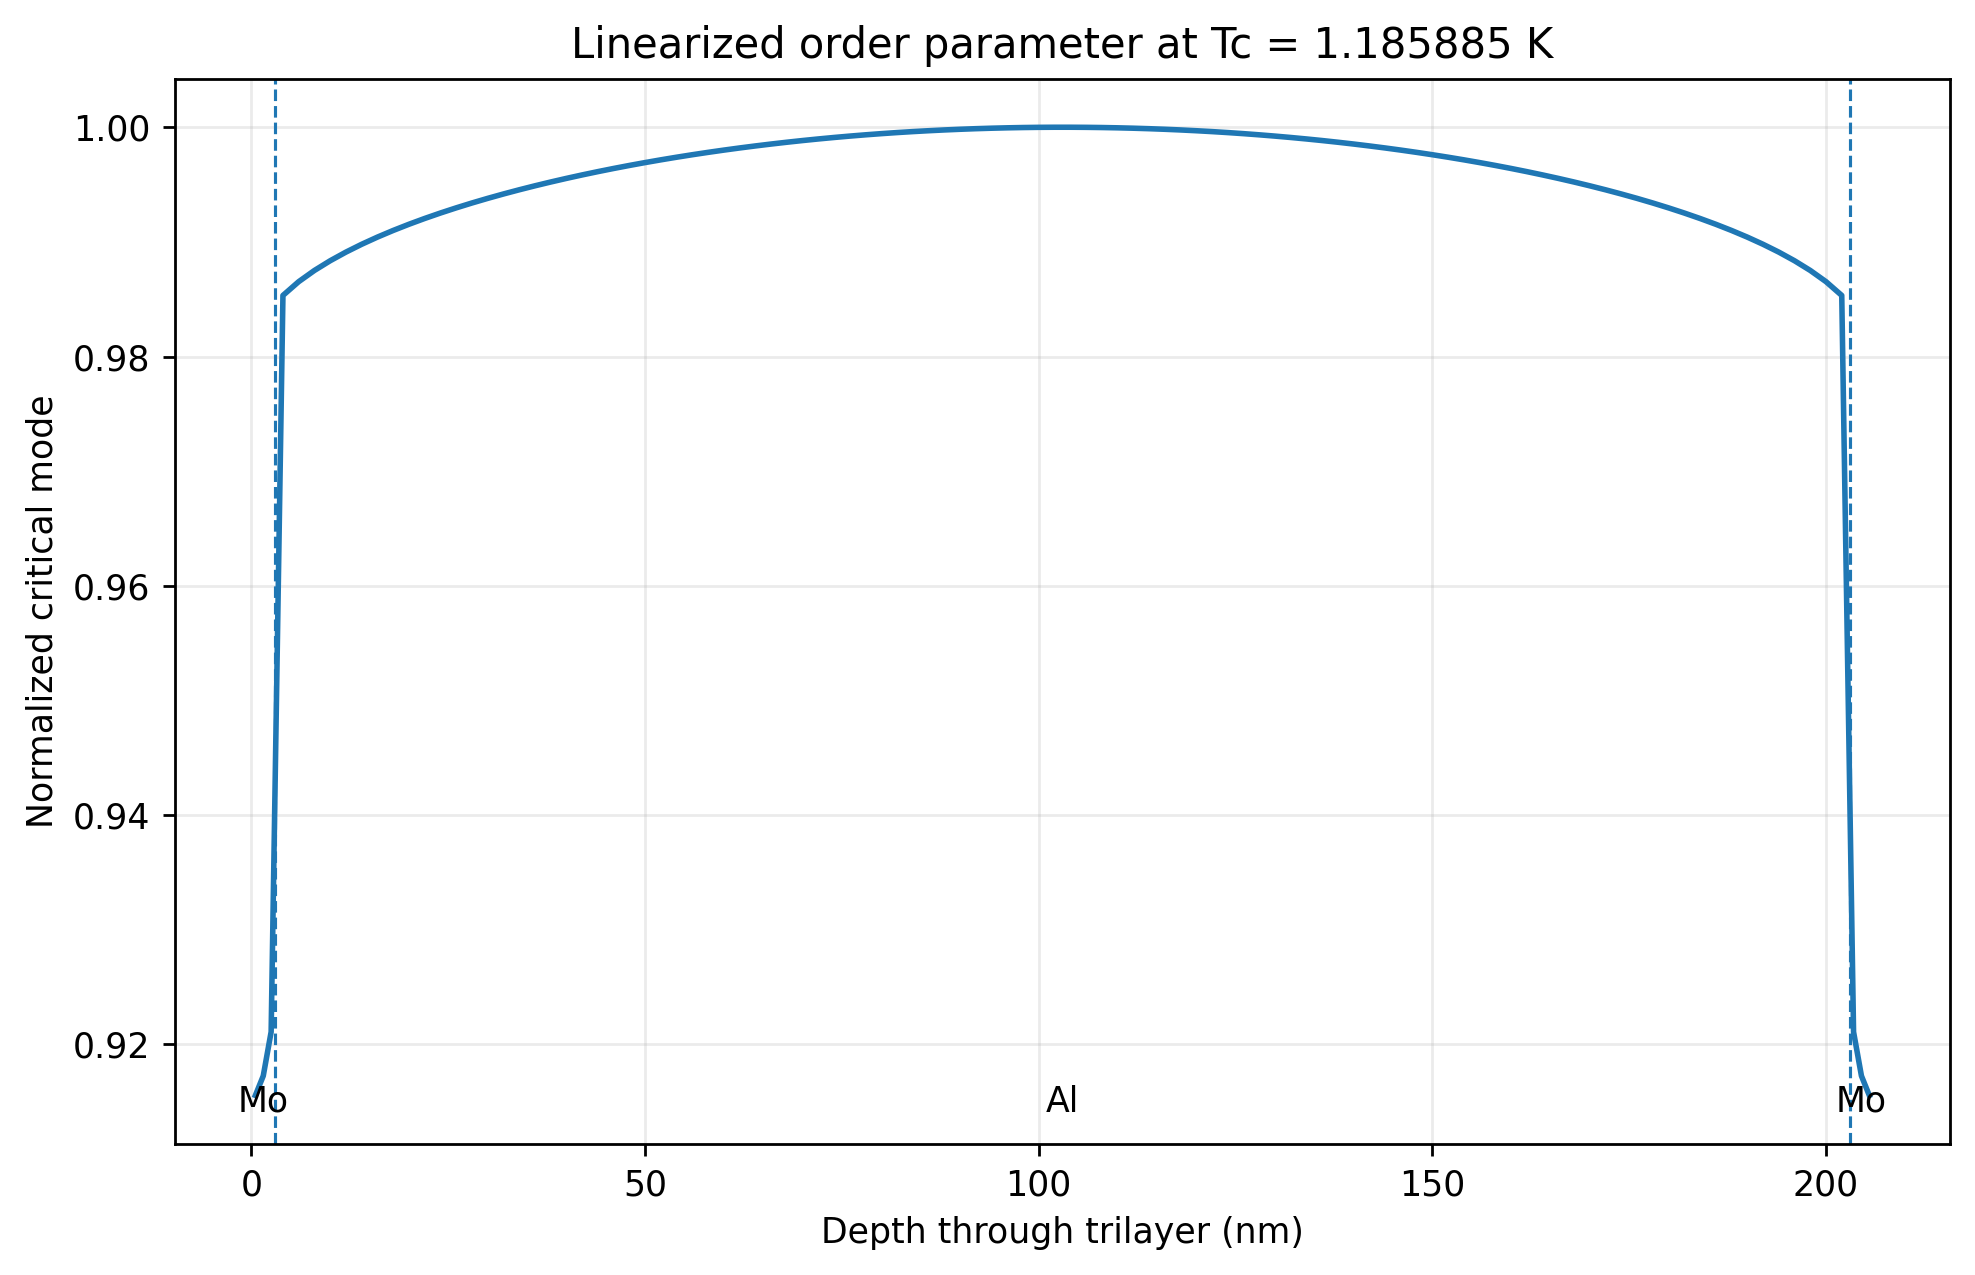

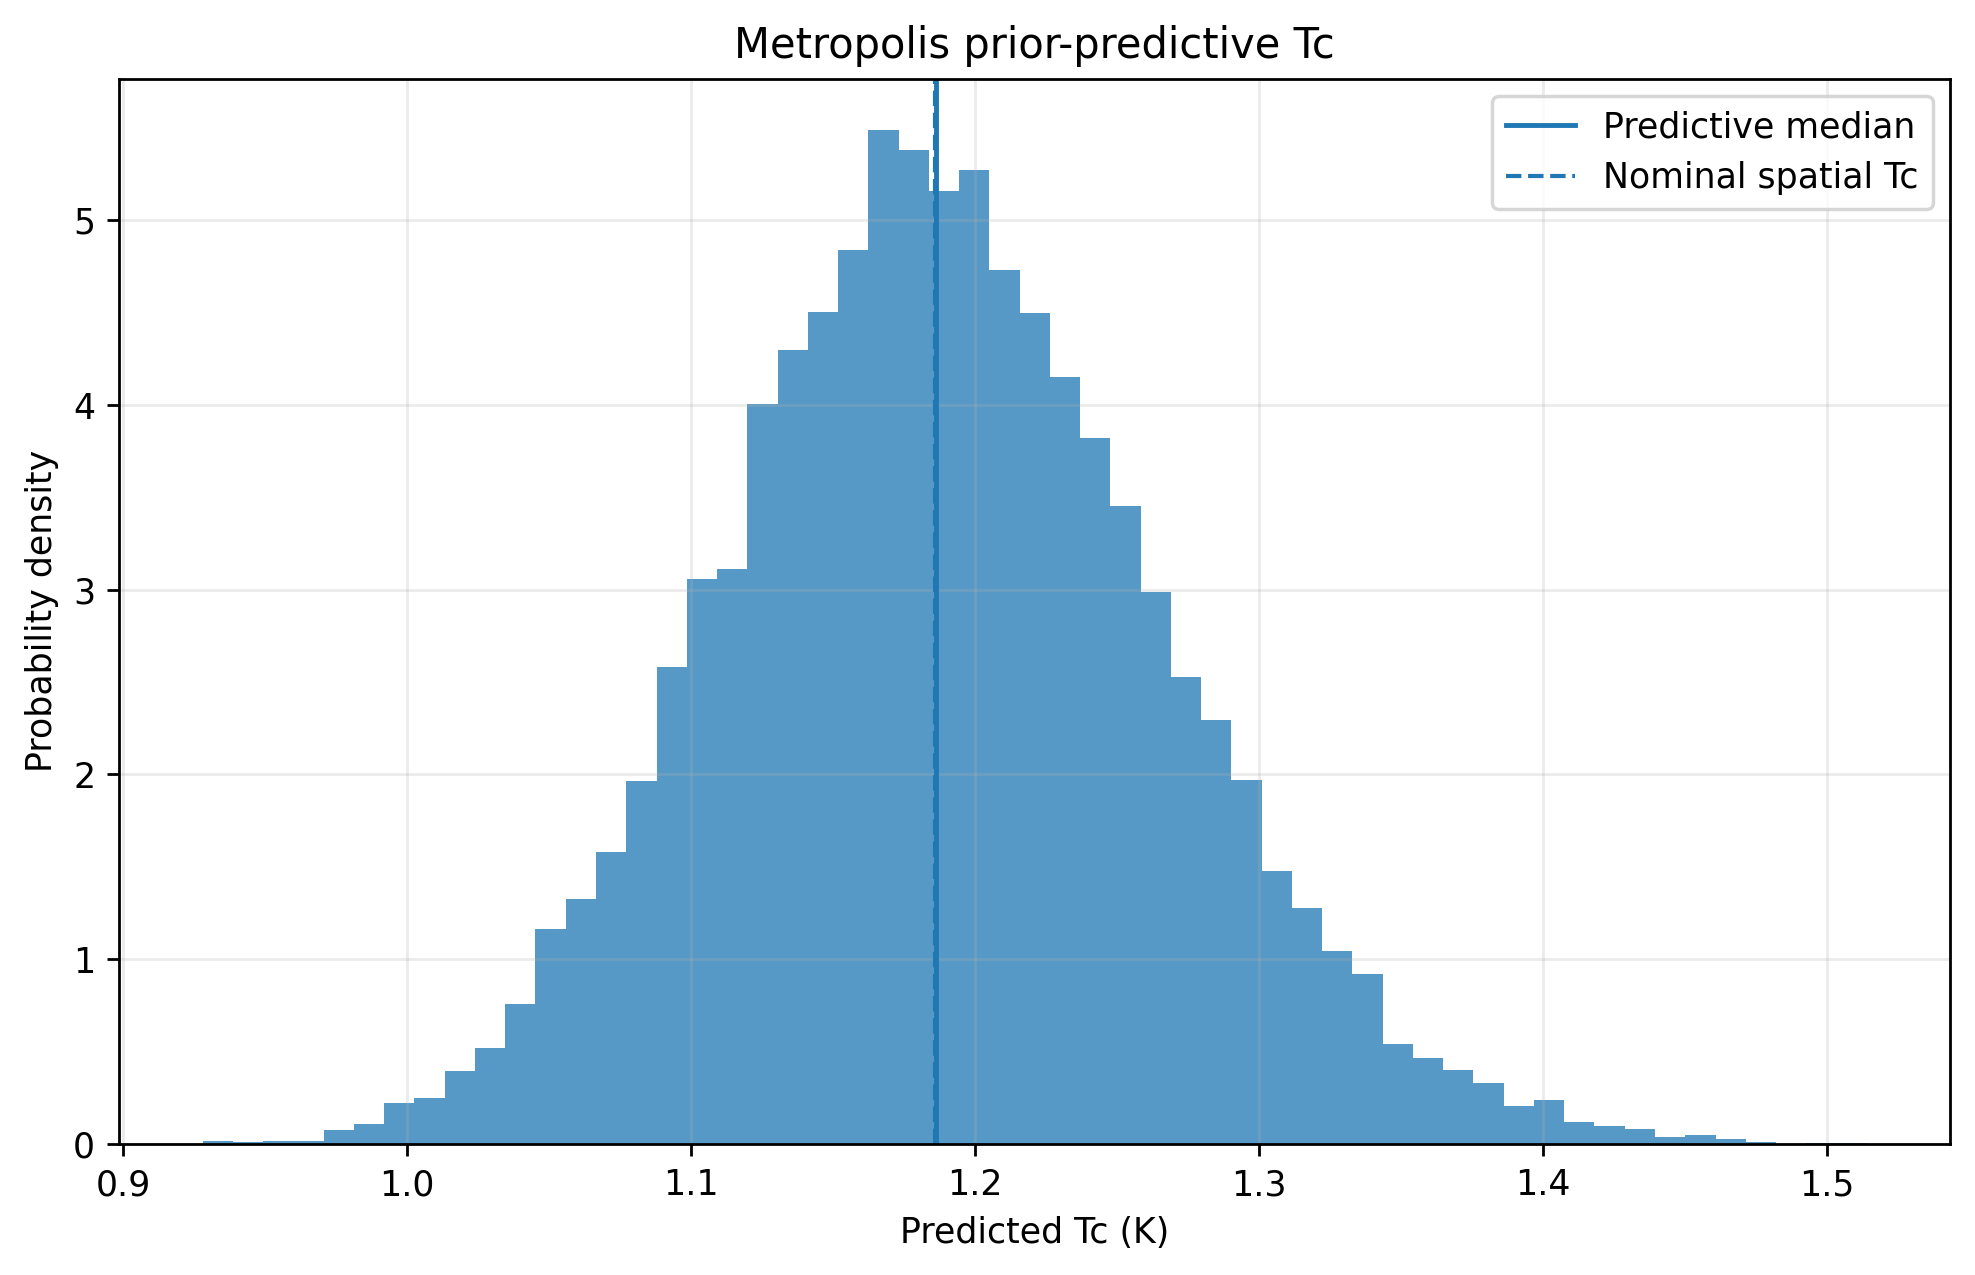

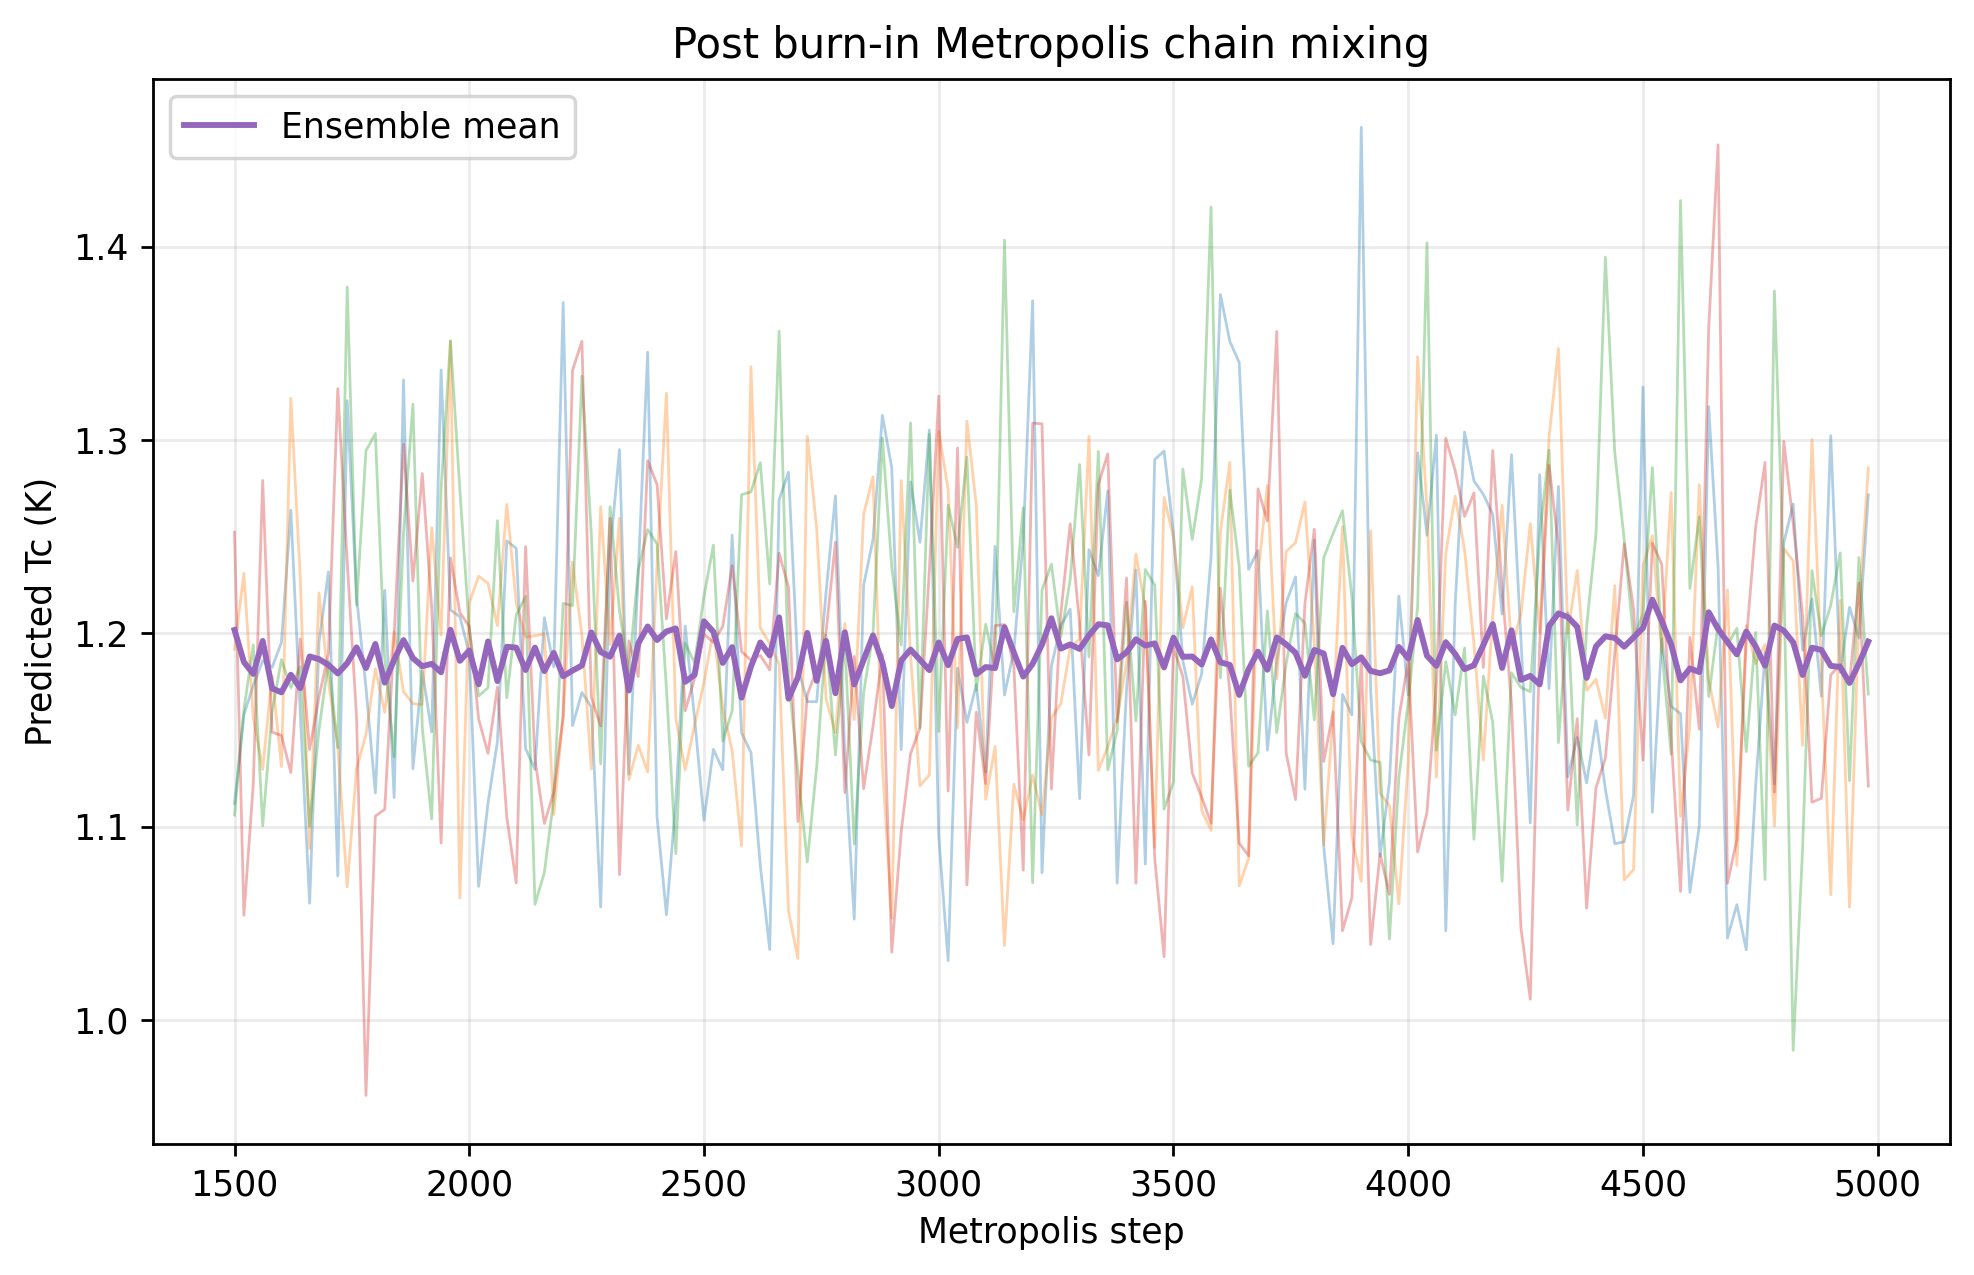

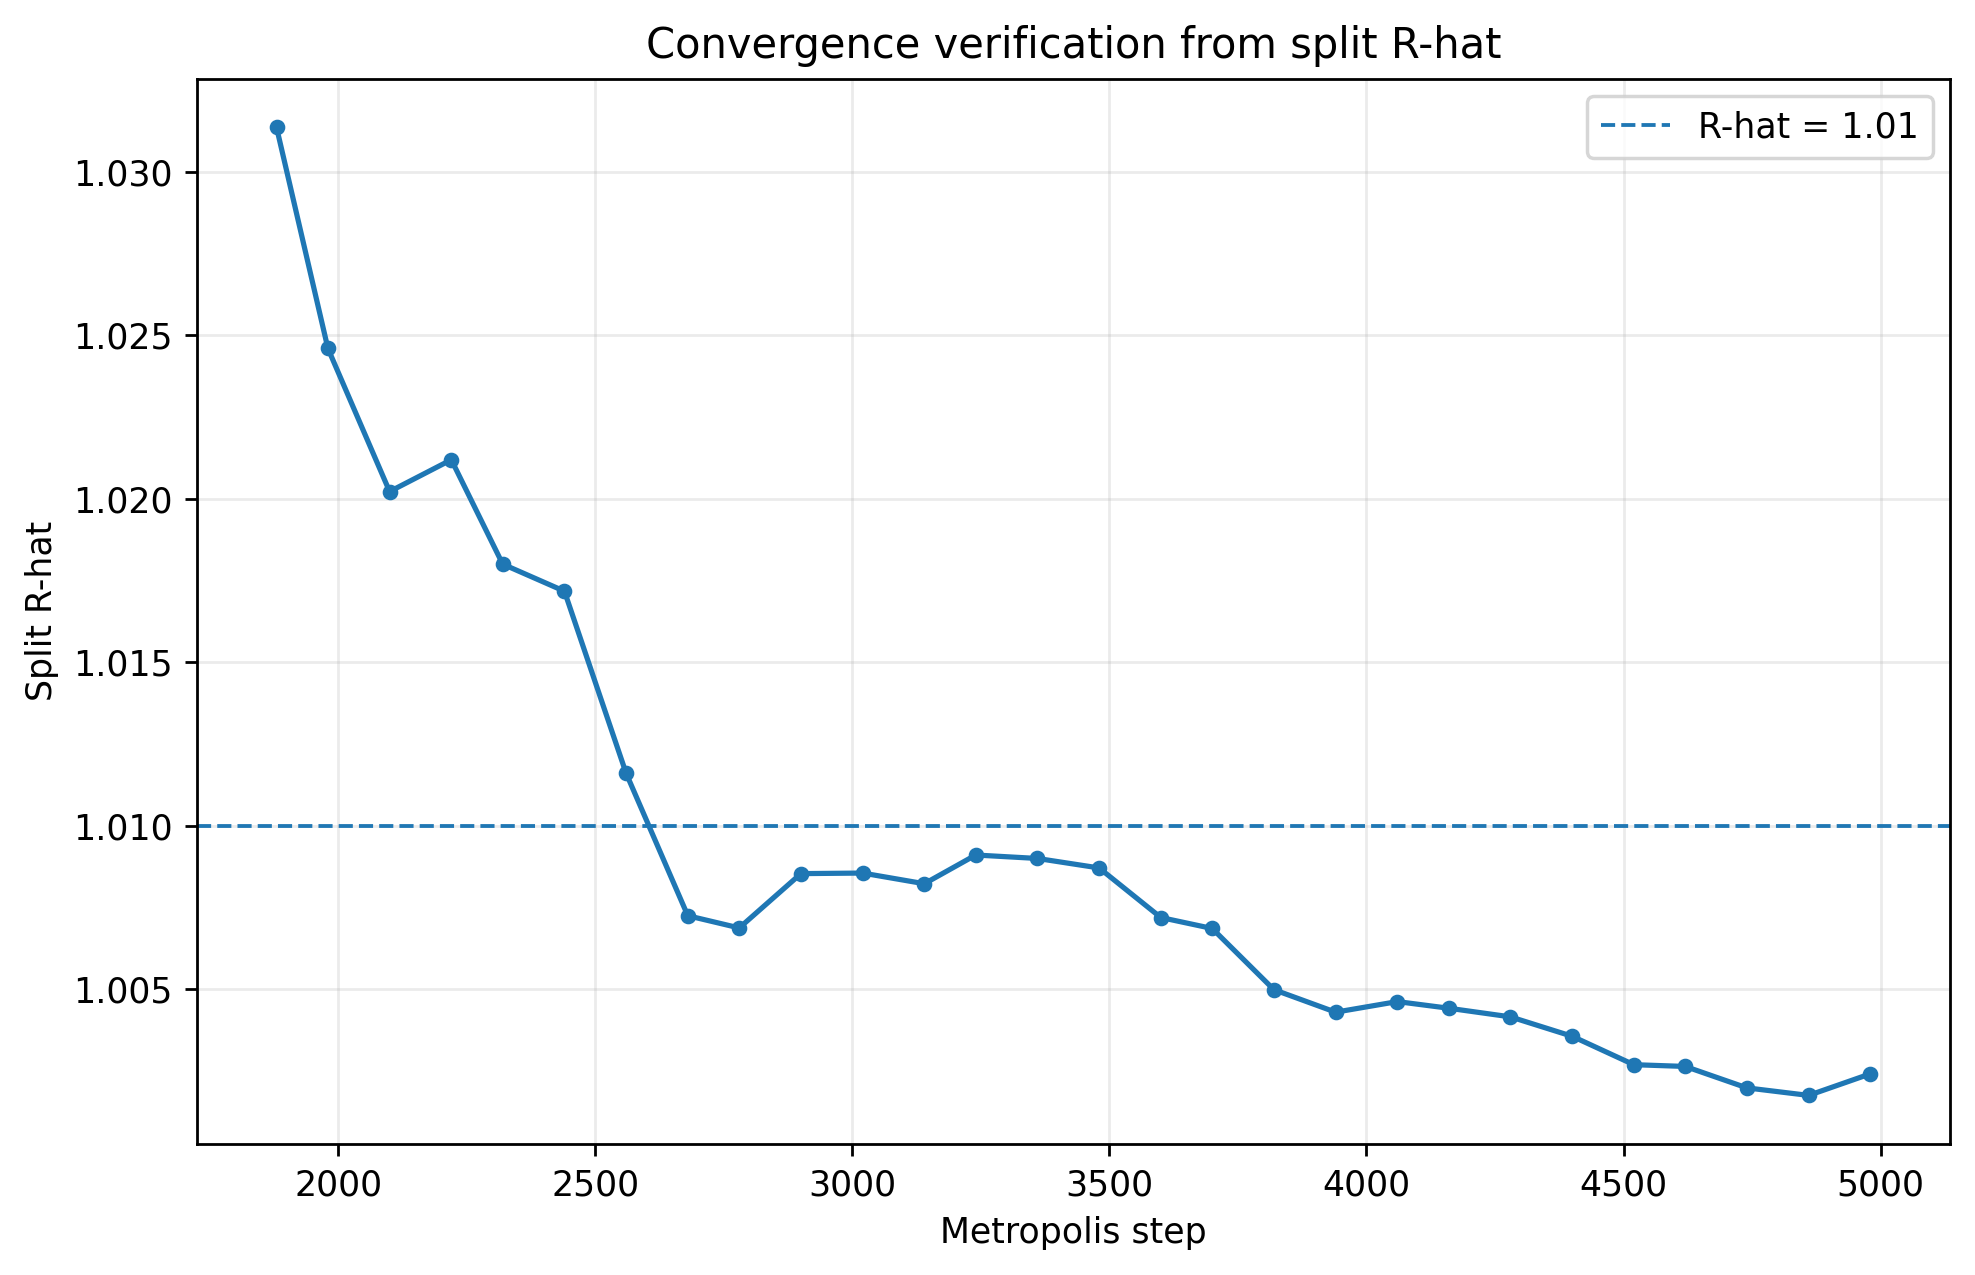

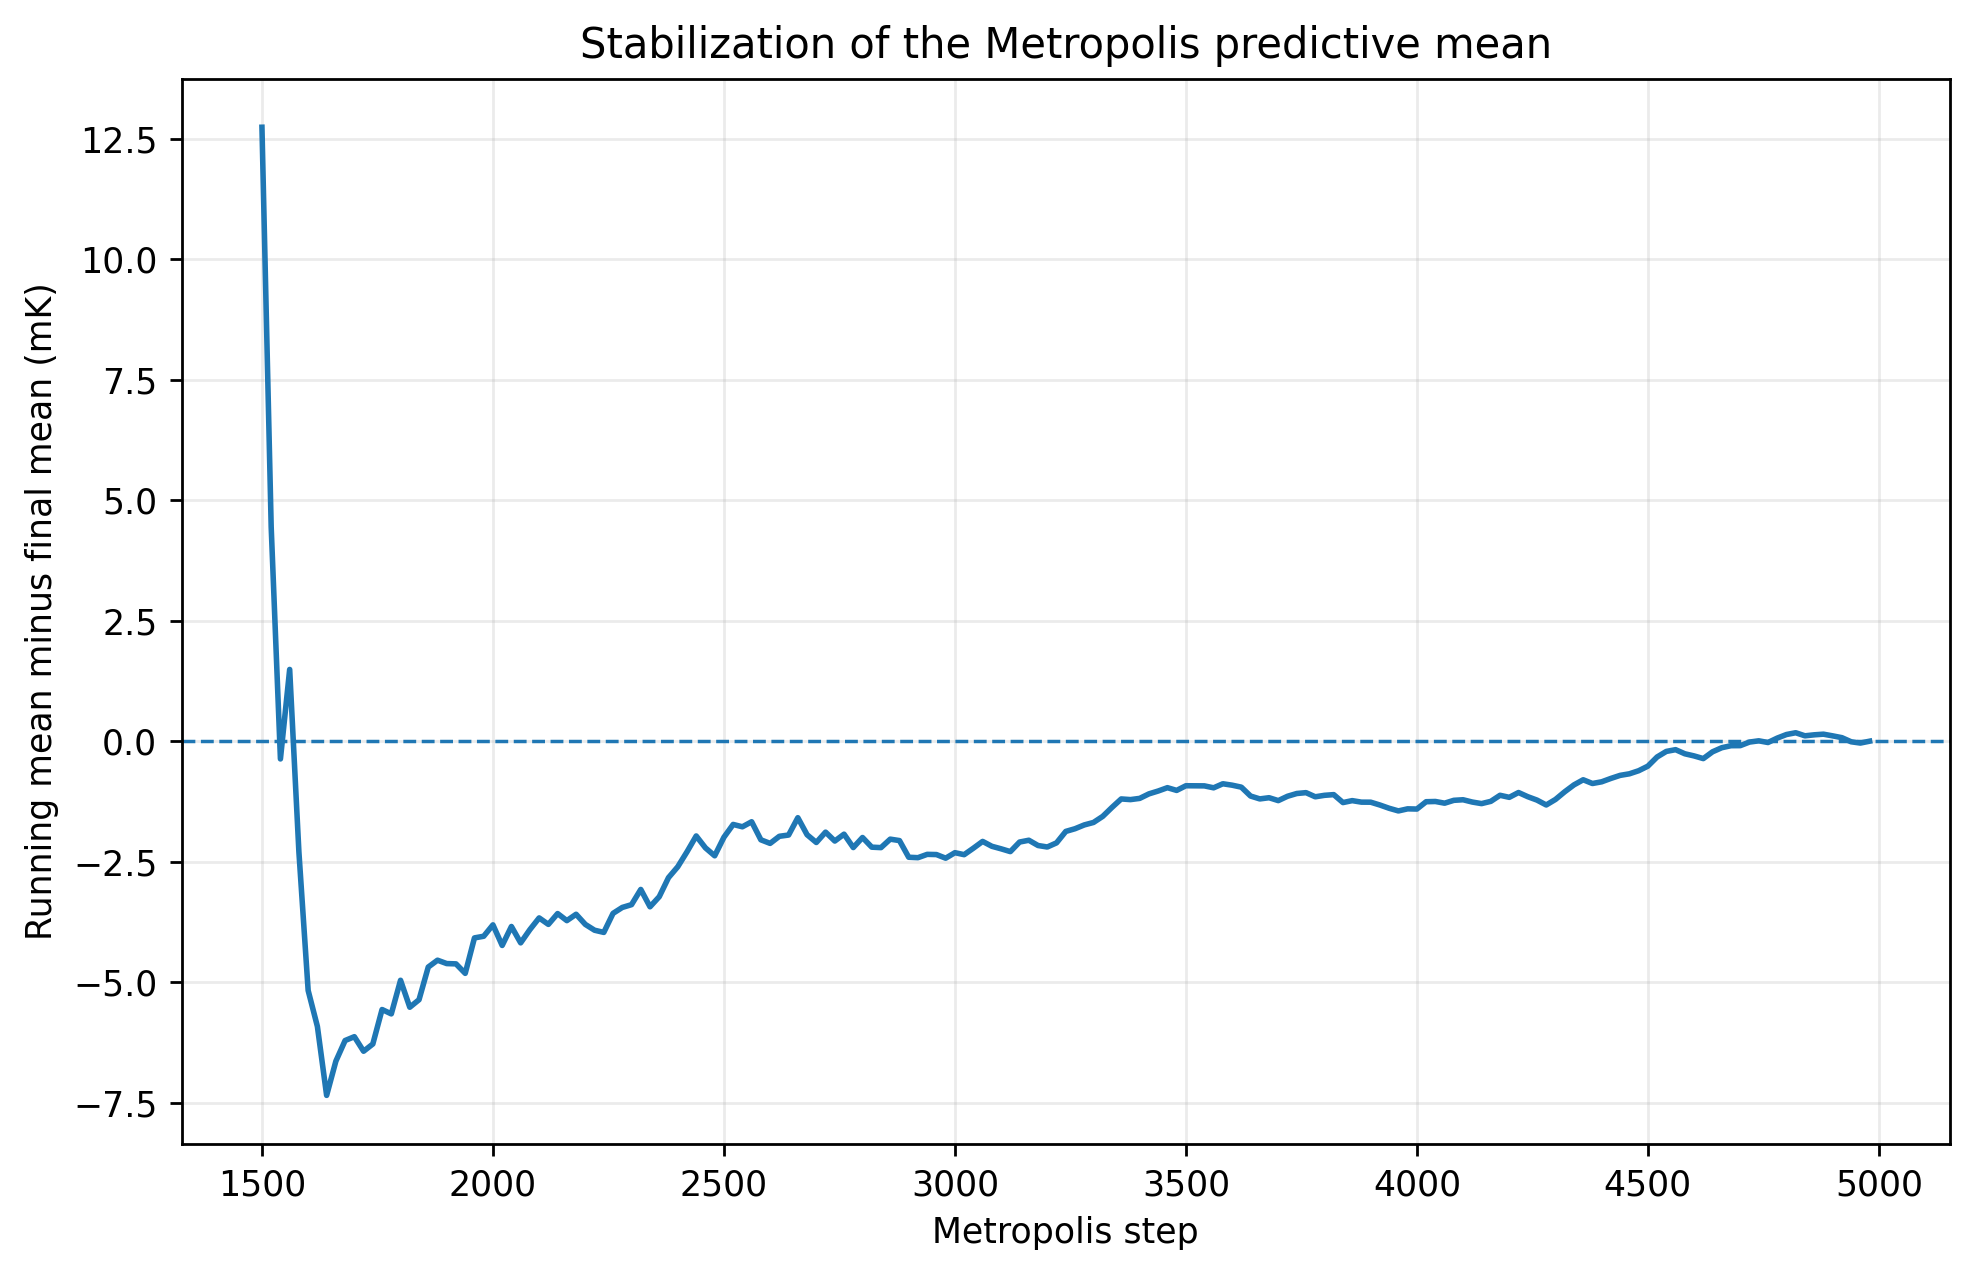

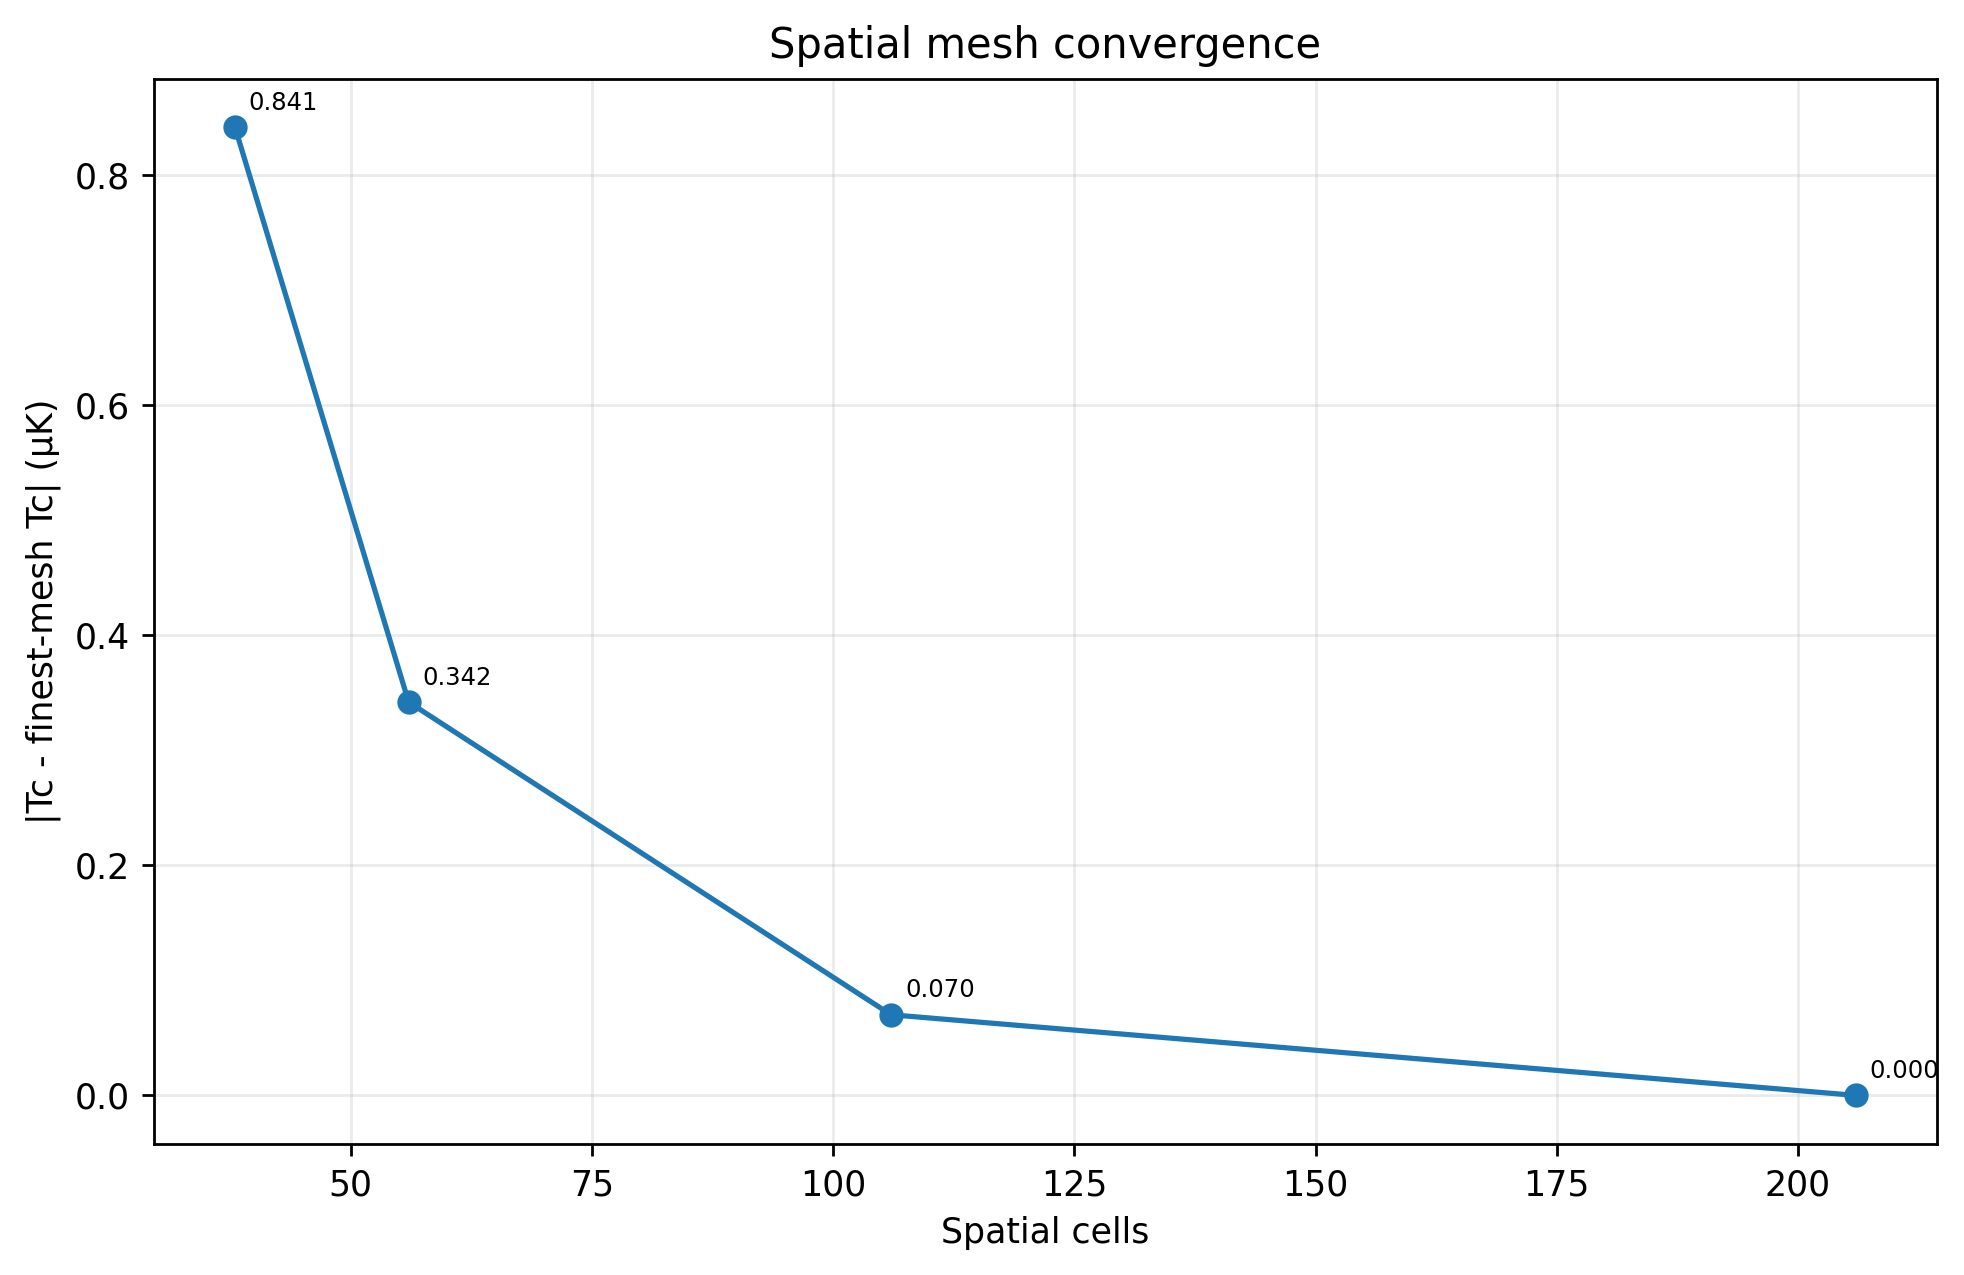

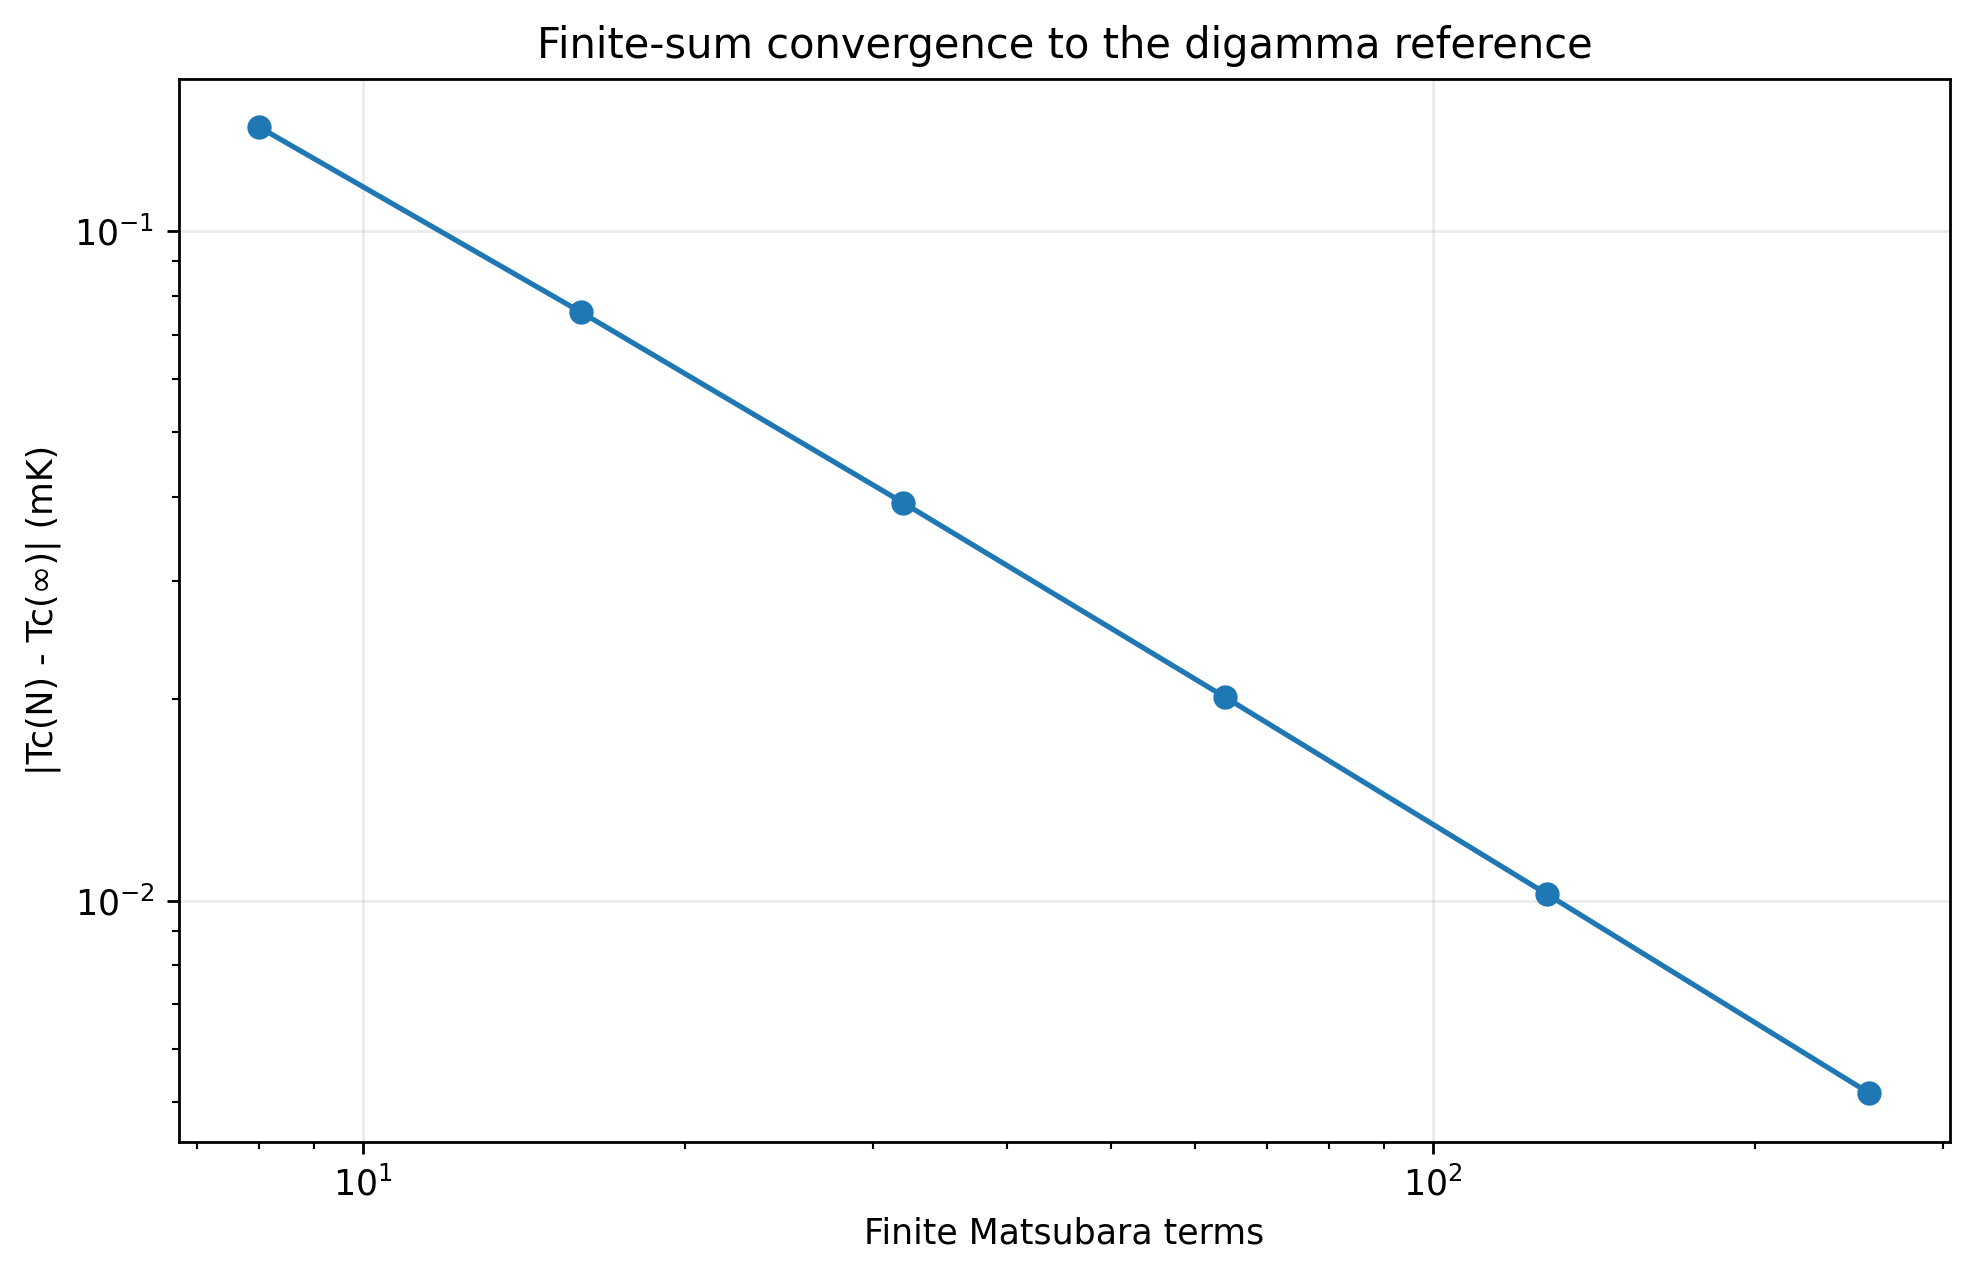

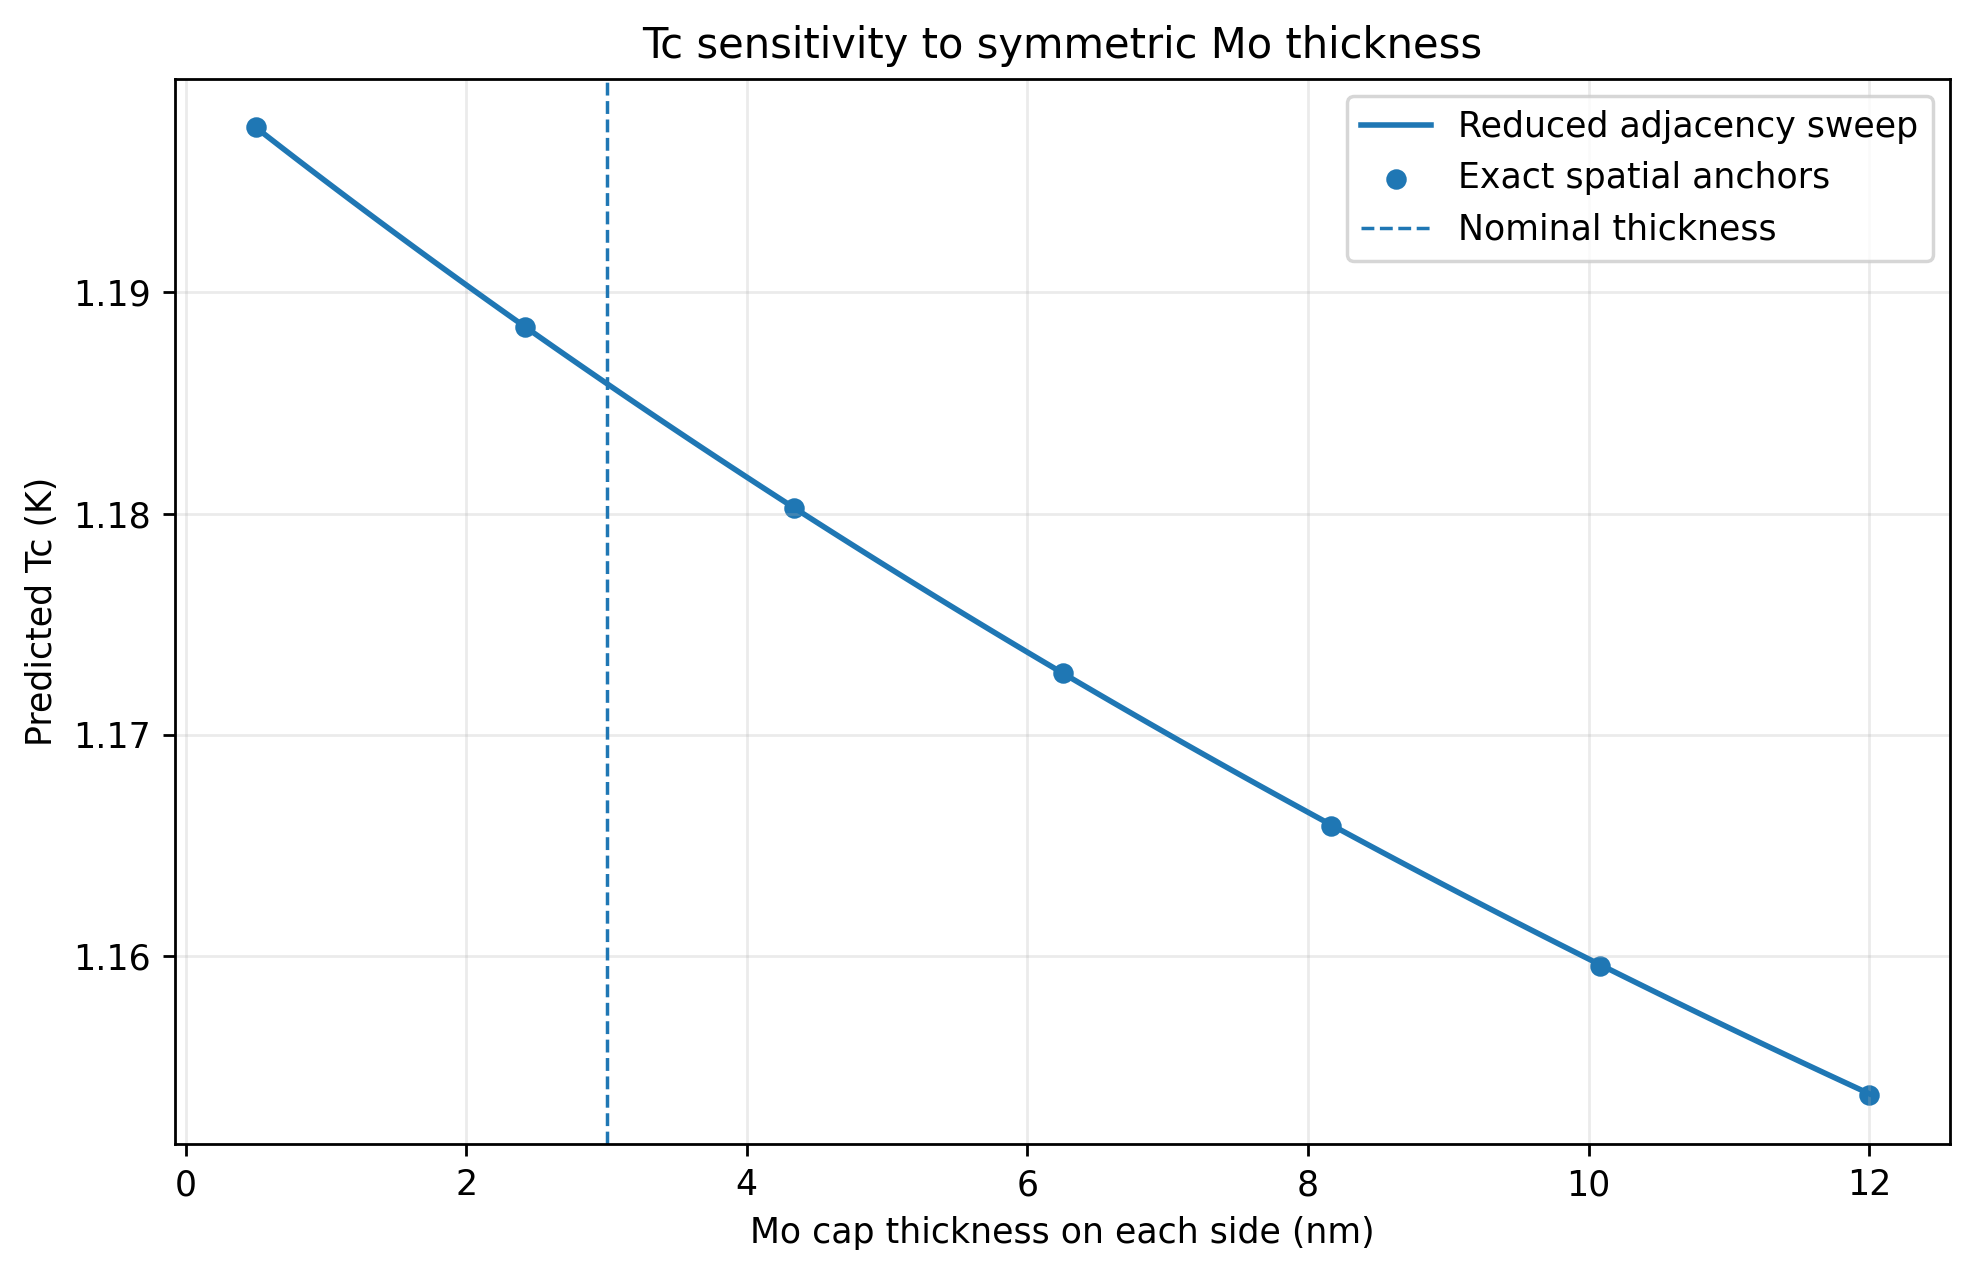

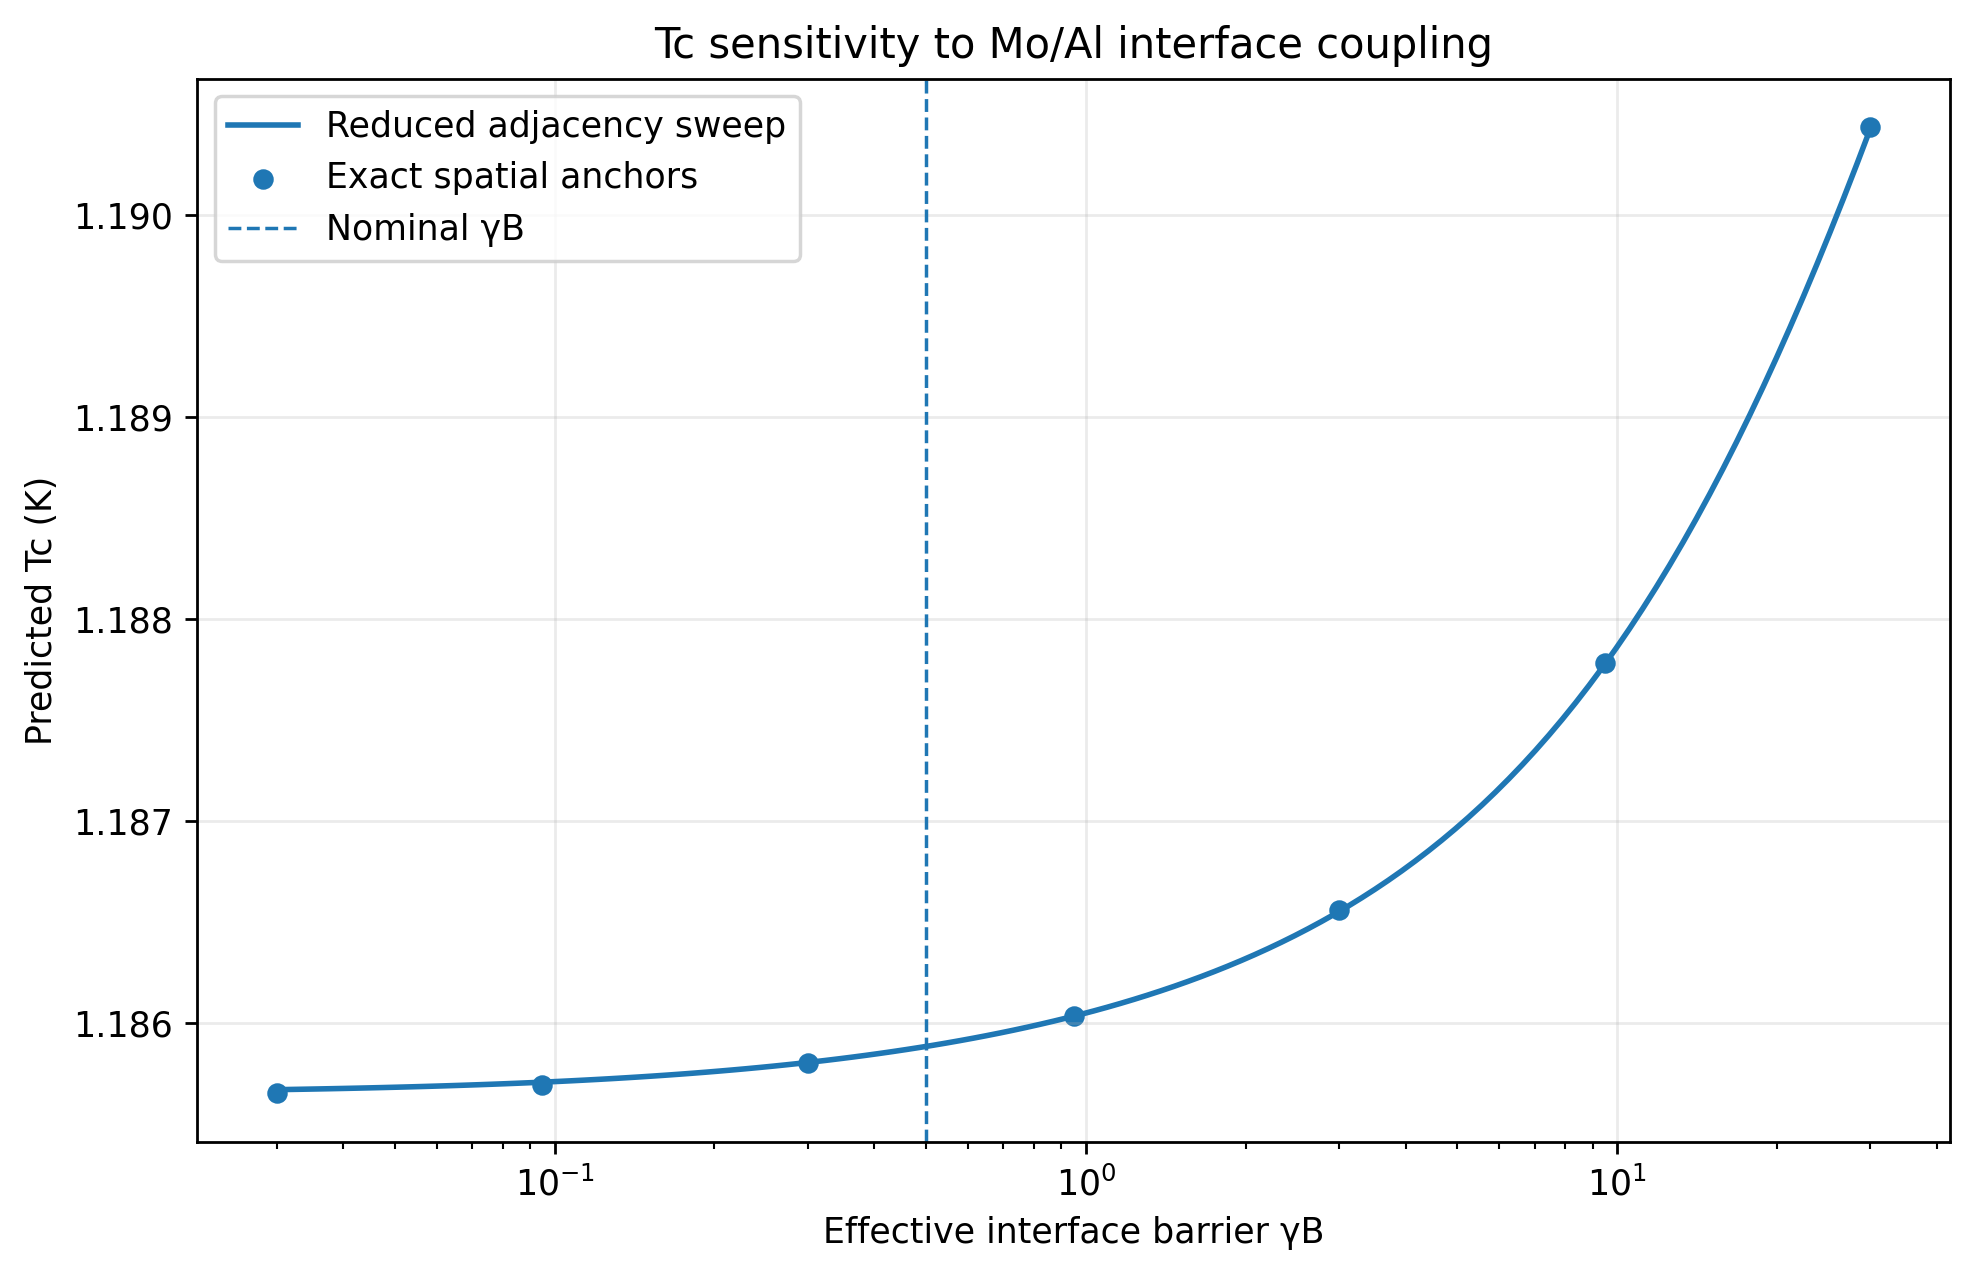

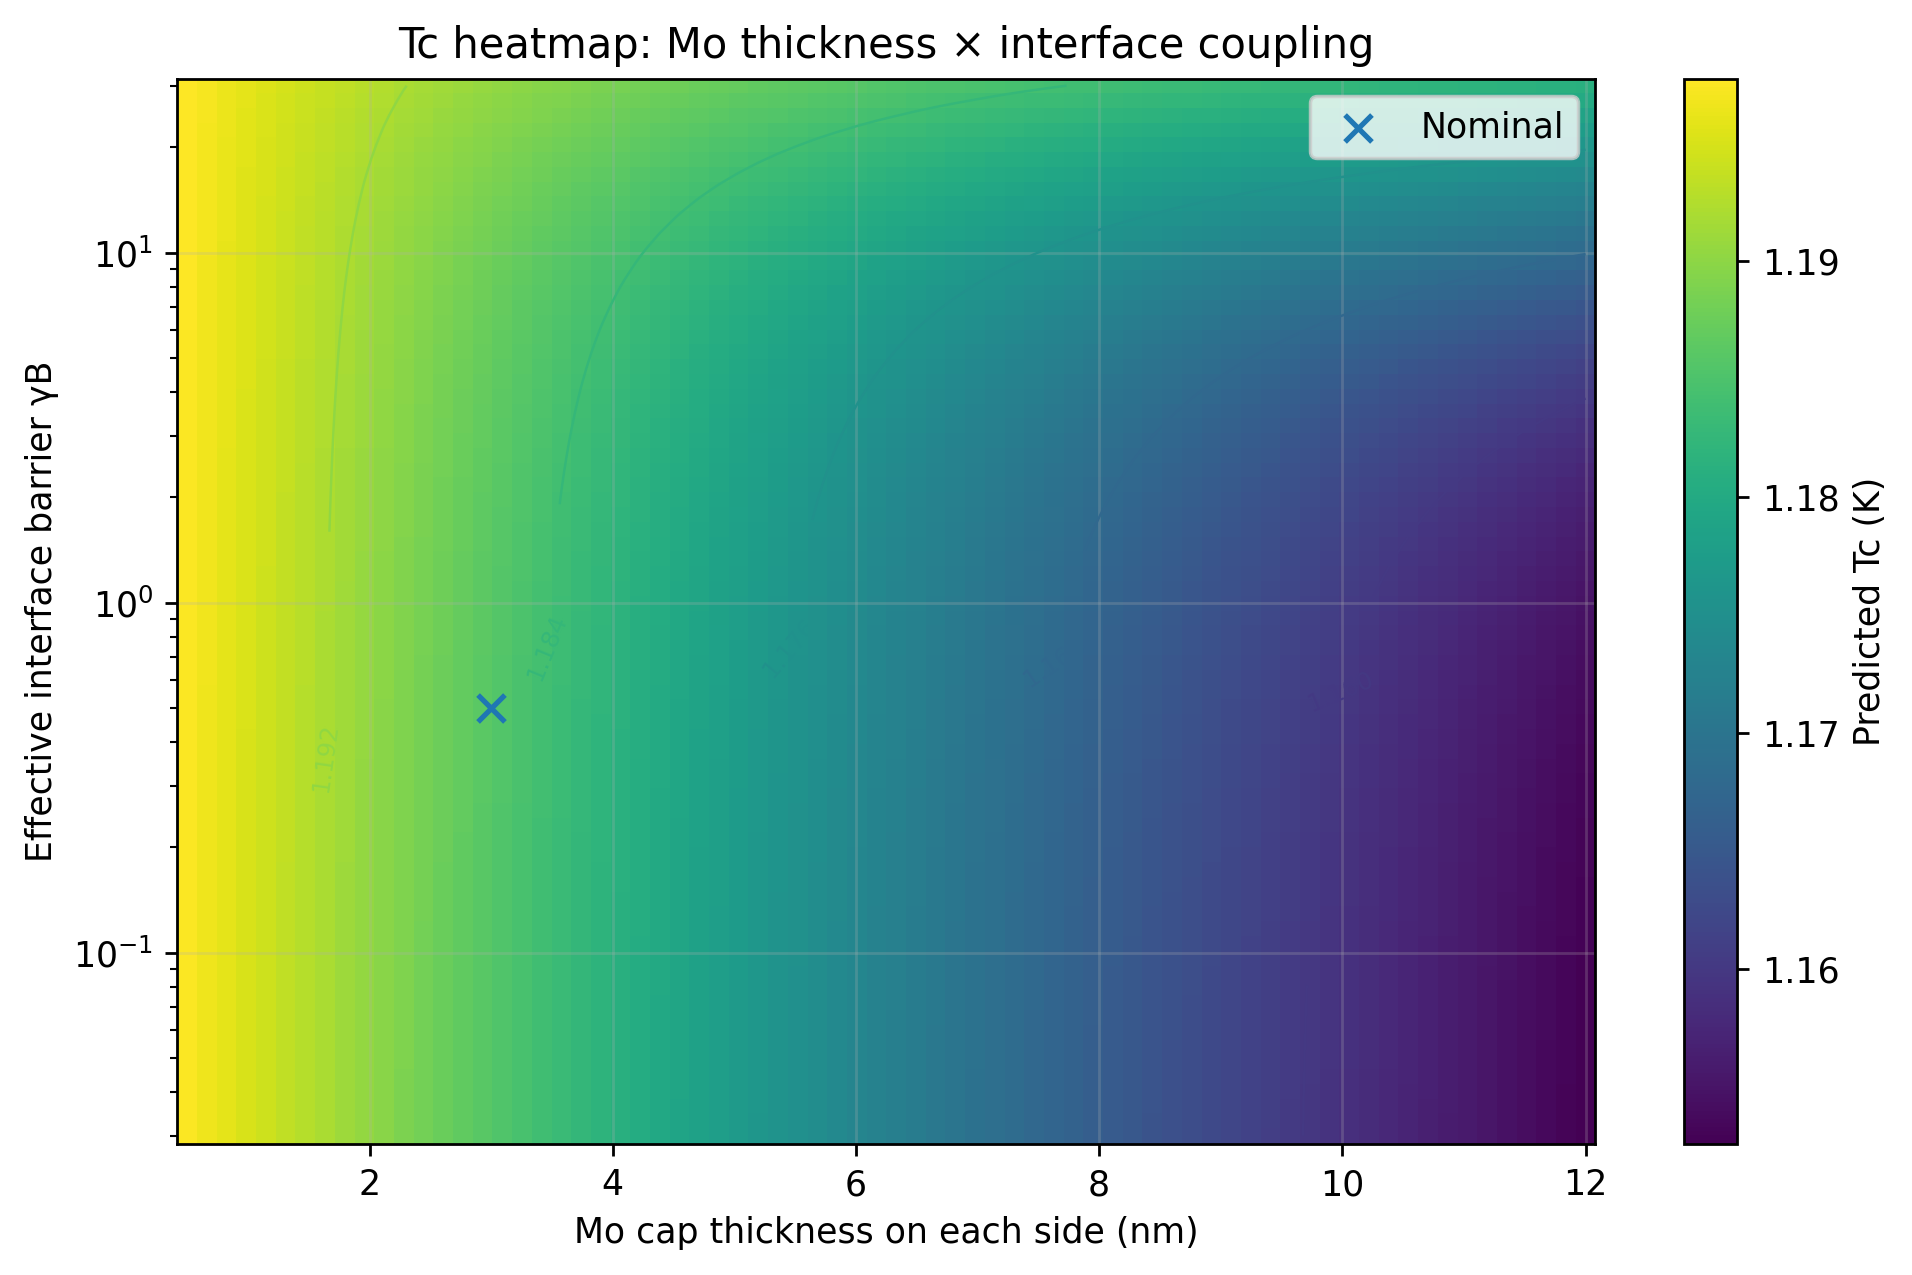

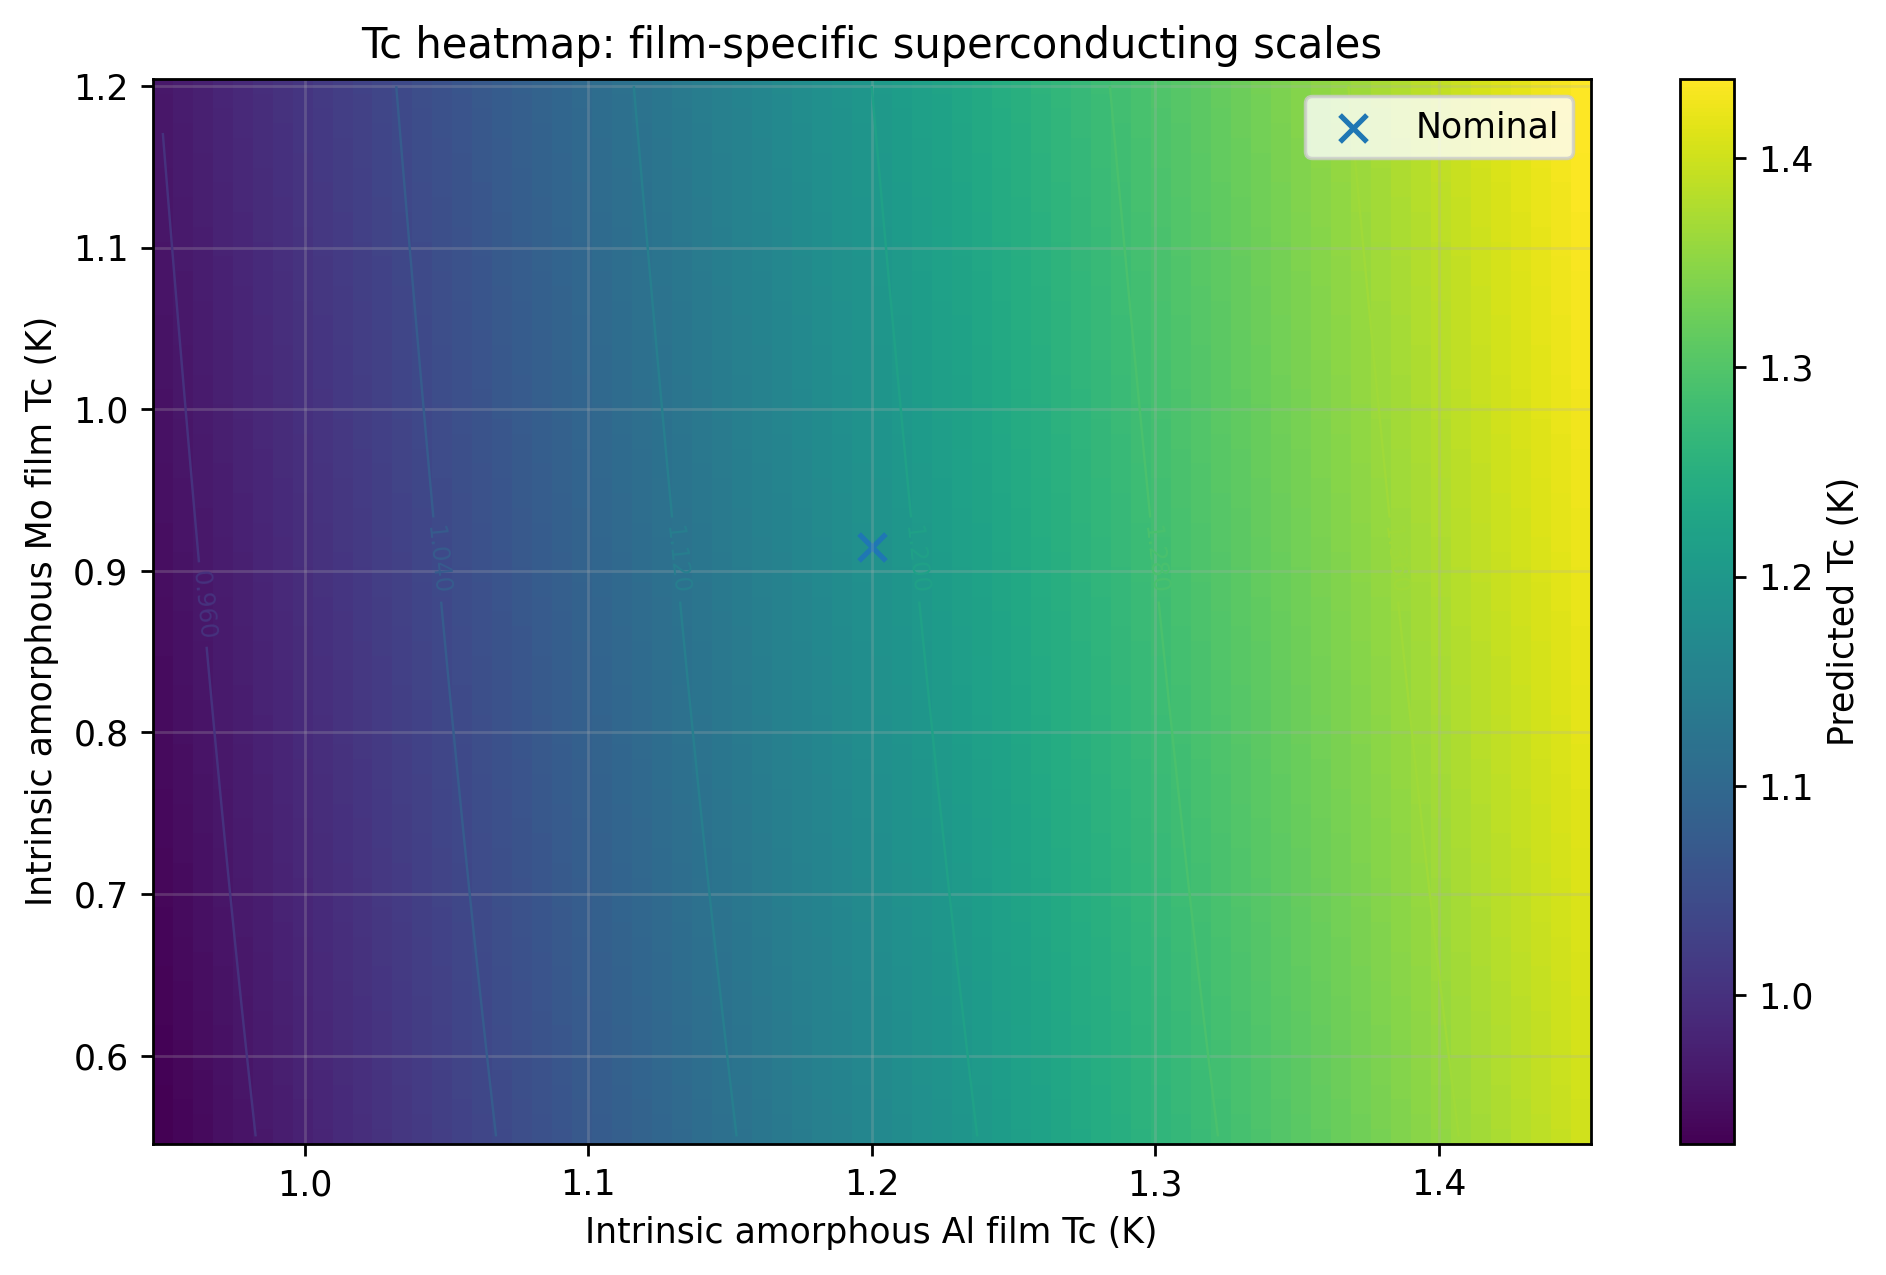

In [3]:
"""GPU estimate of Tc for an amorphous Mo(3)/Al(200)/Mo(3) trilayer.

A dirty-limit linearized Usadel model provides a spatial reference,
while a CUDA-accelerated adaptive Metropolis sampler propagates
uncertainty in film and interface parameters.

The resulting predictive ensemble and parameter maps are accelerated
by a reduced adjacency model and refined via a baseline correction.
"""

import math
from dataclasses import dataclass
from typing import Final, Literal

import cupy as cp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cupyx.scipy import sparse as cpx_sparse
from cupyx.scipy.sparse import linalg as cpx_linalg
from cupyx.scipy.special import digamma


# -----------------------------------------------------------------------------
# Control knobs
# -----------------------------------------------------------------------------

SEED: Final[int] = 31
MO_THICKNESS_NM: Final[float] = 3.0
AL_THICKNESS_NM: Final[float] = 200.0

# These are provisional intrinsic film values. Replace them with standalone
# amorphous-film measurements whenever they are available.
TC_AL_FILM_K: Final[float] = 1.200
TC_MO_FILM_K: Final[float] = 0.915
D_AL_M2_S: Final[float] = 2.5e-3
D_MO_M2_S: Final[float] = 1.5e-4
DOS_RATIO_MO_TO_AL: Final[float] = 1.65
INTERFACE_GAMMA_B: Final[float] = 0.50

AUTO_ADAPT: Final[bool] = True
BASE_DX_NM: Final[float] = 2.0
MESH_POINTS_PER_COHERENCE: Final[float] = 8.0
MIN_CELLS_PER_LAYER: Final[int] = 3
MAX_TOTAL_CELLS: Final[int] = 600

SPARSE_MODE: Final[Literal["auto", "on", "off"]] = "auto"
SPARSE_SWITCH_CELLS: Final[int] = 220
SPARSE_MODAL_RANK: Final[int] = 96
SPARSE_EIG_TOL: Final[float] = 1.0e-8

TC_BISECTION_STEPS: Final[int] = 34
REDUCED_MO_SEGMENTS: Final[int] = 3
REDUCED_AL_SEGMENTS: Final[int] = 9
SURROGATE_BIAS_CORRECTION: Final[bool] = True
SURROGATE_AUDIT_ENABLED: Final[bool] = True
SURROGATE_AUDIT_POINTS: Final[int] = 7
SURROGATE_WARN_MK: Final[float] = 0.15

MCMC_CHAINS: Final[int] = 64
MCMC_STEPS: Final[int] = 5000
MCMC_BURN_IN: Final[int] = 1500
MCMC_THIN: Final[int] = 5
MCMC_TRACE_STRIDE: Final[int] = 20
MCMC_ADAPT_INTERVAL: Final[int] = 100
MCMC_TARGET_ACCEPTANCE: Final[float] = 0.28
MCMC_ADAPT_GAIN: Final[float] = 0.65
MCMC_MAX_TC_SAMPLES: Final[int] = 16000

TC_AL_PRIOR_STD_K: Final[float] = 0.080
TC_MO_PRIOR_STD_K: Final[float] = 0.120
D_AL_LOG_STD: Final[float] = 0.30
D_MO_LOG_STD: Final[float] = 0.45
DOS_RATIO_LOG_STD: Final[float] = 0.25
GAMMA_B_LOG_STD: Final[float] = 0.65

HEATMAP_POINTS: Final[int] = 72
MO_SWEEP_NM: Final[tuple[float, float]] = (0.5, 12.0)
GAMMA_SWEEP: Final[tuple[float, float]] = (0.03, 30.0)
TC_AL_SWEEP_K: Final[tuple[float, float]] = (0.95, 1.45)
TC_MO_SWEEP_K: Final[tuple[float, float]] = (0.55, 1.20)
MATSUBARA_TERMS: Final[tuple[int, ...]] = (8, 16, 32, 64, 128, 256)
MESH_DX_TEST_NM: Final[tuple[float, ...]] = (8.0, 4.0, 2.0, 1.0)

FIGURE_DPI: Final[int] = 250
FIGURE_SIZE: Final[tuple[float, float]] = (8.0, 5.2)

HBAR: Final[float] = 1.054_571_817e-34
K_B: Final[float] = 1.380_649e-23
DIGAMMA_HALF: Final[float] = -1.963_510_026_021_423_5

PARAMETER_NAMES: Final[tuple[str, ...]] = (
    "tc_al_k",
    "tc_mo_k",
    "d_al_m2_s",
    "d_mo_m2_s",
    "dos_ratio",
    "gamma_b",
)


@dataclass
class SpectralModel:
    """Store the spatial adjacency eigensystem used by the Usadel solver."""

    x_nm: cp.ndarray
    tc0_k: cp.ndarray
    q_weight: cp.ndarray
    eigenvalues_k: cp.ndarray
    eigenvectors: cp.ndarray
    sparse_active: bool
    modal_rank: int


def configure_plots() -> None:
    """Configure notebook plotting defaults."""

    mpl.rcParams["figure.dpi"] = FIGURE_DPI
    mpl.rcParams["savefig.dpi"] = FIGURE_DPI
    mpl.rcParams["axes.grid"] = True
    mpl.rcParams["grid.alpha"] = 0.25


def coherence_nm(diffusivity_m2_s: float, tc_k: float) -> float:
    """Return the dirty-limit thermal coherence length in nanometres."""

    kappa = HBAR * diffusivity_m2_s / (2.0 * K_B) * 1.0e18
    return math.sqrt(kappa / (math.pi * tc_k))


def use_sparse(n_cells: int, override: str | None = None) -> bool:
    """Resolve the sparse low-mode policy for the current spatial problem."""

    mode = SPARSE_MODE if override is None else override
    if mode == "on":
        return True
    if mode == "off":
        return False
    return n_cells >= SPARSE_SWITCH_CELLS


def build_model(
    tc_al_k: float = TC_AL_FILM_K,
    tc_mo_k: float = TC_MO_FILM_K,
    d_al_m2_s: float = D_AL_M2_S,
    d_mo_m2_s: float = D_MO_M2_S,
    dos_ratio: float = DOS_RATIO_MO_TO_AL,
    gamma_b: float = INTERFACE_GAMMA_B,
    mo_thickness_nm: float = MO_THICKNESS_NM,
    al_thickness_nm: float = AL_THICKNESS_NM,
    base_dx_nm: float = BASE_DX_NM,
    sparse_override: str | None = None,
) -> SpectralModel:
    """Build the adaptive finite-volume spectral adjacency operator."""

    layers = (
        (mo_thickness_nm, tc_mo_k, d_mo_m2_s, dos_ratio),
        (al_thickness_nm, tc_al_k, d_al_m2_s, 1.0),
        (mo_thickness_nm, tc_mo_k, d_mo_m2_s, dos_ratio),
    )
    counts = []
    for thickness, tc_k, diffusivity, _ in layers:
        target_dx = base_dx_nm
        if AUTO_ADAPT:
            target_dx = min(
                base_dx_nm,
                coherence_nm(diffusivity, tc_k) / MESH_POINTS_PER_COHERENCE,
            )
        counts.append(
            max(MIN_CELLS_PER_LAYER, int(math.ceil(thickness / target_dx)))
        )

    if sum(counts) > MAX_TOTAL_CELLS:
        scale = sum(counts) / MAX_TOTAL_CELLS
        counts = [
            max(MIN_CELLS_PER_LAYER, int(math.ceil(value / scale)))
            for value in counts
        ]

    x_values, dx_values, layer_values = [], [], []
    tc_values, d_values, dos_values = [], [], []
    z_nm = 0.0
    for layer_id, (layer, count) in enumerate(zip(layers, counts, strict=True)):
        thickness, tc_k, diffusivity, dos_rel = layer
        dx_nm = thickness / count
        for cell in range(count):
            x_values.append(z_nm + (cell + 0.5) * dx_nm)
            dx_values.append(dx_nm)
            layer_values.append(layer_id)
            tc_values.append(tc_k)
            d_values.append(diffusivity)
            dos_values.append(dos_rel)
        z_nm += thickness

    x_nm = cp.asarray(x_values, dtype=cp.float64)
    dx_nm = cp.asarray(dx_values, dtype=cp.float64)
    layer_id = cp.asarray(layer_values, dtype=cp.int32)
    tc0_k = cp.asarray(tc_values, dtype=cp.float64)
    diffusivity = cp.asarray(d_values, dtype=cp.float64)
    dos_rel = cp.asarray(dos_values, dtype=cp.float64)

    kappa = HBAR * diffusivity / (2.0 * K_B) * 1.0e18
    xi_nm = cp.sqrt(kappa / (cp.pi * tc0_k))
    q_weight = dos_rel * dx_nm

    resistance = dx_nm[:-1] / (2.0 * dos_rel[:-1] * kappa[:-1])
    resistance += dx_nm[1:] / (2.0 * dos_rel[1:] * kappa[1:])
    interface = layer_id[:-1] != layer_id[1:]
    r_left = xi_nm[:-1] / (dos_rel[:-1] * kappa[:-1])
    r_right = xi_nm[1:] / (dos_rel[1:] * kappa[1:])
    resistance += cp.where(
        interface,
        gamma_b * cp.sqrt(r_left * r_right),
        0.0,
    )
    edge_g = 1.0 / resistance

    diagonal = cp.zeros_like(q_weight)
    diagonal[:-1] += edge_g
    diagonal[1:] += edge_g
    diagonal /= q_weight
    off = -edge_g / cp.sqrt(q_weight[:-1] * q_weight[1:])
    n_cells = int(q_weight.size)

    sparse_active = use_sparse(n_cells, sparse_override)
    if sparse_active:
        laplacian = cpx_sparse.diags((off, diagonal, off), (-1, 0, 1), format="csr")
        modal_rank = min(SPARSE_MODAL_RANK, n_cells - 2)
        eigenvalues, eigenvectors = cpx_linalg.eigsh(
            laplacian,
            k=modal_rank,
            which="SA",
            tol=SPARSE_EIG_TOL,
        )
        order = cp.argsort(eigenvalues)
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]
    else:
        laplacian = cp.diag(diagonal) + cp.diag(off, 1) + cp.diag(off, -1)
        eigenvalues, eigenvectors = cp.linalg.eigh(laplacian)
        modal_rank = n_cells

    return SpectralModel(
        x_nm=x_nm,
        tc0_k=tc0_k,
        q_weight=q_weight,
        eigenvalues_k=cp.maximum(eigenvalues, 0.0),
        eigenvectors=eigenvectors,
        sparse_active=sparse_active,
        modal_rank=modal_rank,
    )


def kernel_modes(
    eigenvalues_k: cp.ndarray,
    temperature_k: float,
    matsubara_terms: int | None = None,
) -> cp.ndarray:
    """Evaluate the convergent Matsubara kernel in adjacency eigenmode space."""

    if matsubara_terms is None:
        argument = 0.5 + eigenvalues_k / (2.0 * cp.pi * temperature_k)
        return digamma(argument) - DIGAMMA_HALF

    n = cp.arange(matsubara_terms, dtype=cp.float64)
    odd = 2.0 * n + 1.0
    reduced = eigenvalues_k[:, None] / (cp.pi * temperature_k)
    return cp.sum(
        2.0 * (1.0 / odd[None, :] - 1.0 / (odd[None, :] + reduced)),
        axis=1,
    )


def self_matrix(
    model: SpectralModel,
    temperature_k: float,
    matsubara_terms: int | None = None,
) -> cp.ndarray:
    """Build the linearized self-consistency matrix at one temperature."""

    g_modes = kernel_modes(model.eigenvalues_k, temperature_k, matsubara_terms)
    log_pairing = cp.log(temperature_k / model.tc0_k)
    vectors = model.eigenvectors

    if model.sparse_active:
        matrix = vectors.T @ (log_pairing[:, None] * vectors)
        index = cp.arange(model.modal_rank)
        matrix[index, index] += g_modes
        return matrix

    matrix = (vectors * g_modes[None, :]) @ vectors.T
    index = cp.arange(model.tc0_k.size)
    matrix[index, index] += log_pairing
    return matrix


def solve_tc(model: SpectralModel, matsubara_terms: int | None = None) -> float:
    """Find Tc from the zero crossing of the lowest self-consistency eigenvalue."""

    tc_values = cp.asnumpy(model.tc0_k)
    low = 0.25 * float(np.min(tc_values))
    high = 1.20 * float(np.max(tc_values))

    def minimum(temperature_k: float) -> float:
        value = cp.linalg.eigvalsh(
            self_matrix(model, temperature_k, matsubara_terms)
        )[0]
        return float(cp.asnumpy(value))

    if minimum(low) >= 0.0 or minimum(high) <= 0.0:
        raise RuntimeError("Tc root is outside the configured temperature bracket.")

    for _ in range(TC_BISECTION_STEPS):
        middle = 0.5 * (low + high)
        if minimum(middle) < 0.0:
            low = middle
        else:
            high = middle
    return 0.5 * (low + high)


def critical_profile(model: SpectralModel, tc_k: float) -> cp.ndarray:
    """Return the normalized critical order-parameter eigenmode."""

    _, vectors = cp.linalg.eigh(self_matrix(model, tc_k))
    transformed = vectors[:, 0]
    if model.sparse_active:
        transformed = model.eigenvectors @ transformed
    gap = transformed / cp.sqrt(model.q_weight)
    if float(cp.asnumpy(cp.sum(gap))) < 0.0:
        gap = -gap
    return gap / cp.max(cp.abs(gap))


def _flat_broadcast(*values: float | cp.ndarray) -> list[cp.ndarray]:
    """Broadcast scalar or array inputs into flat GPU vectors."""

    arrays = [cp.asarray(value, dtype=cp.float64) for value in values]
    return [array.reshape(-1) for array in cp.broadcast_arrays(*arrays)]


def reduced_batch_tc(
    tc_al_k: float | cp.ndarray,
    tc_mo_k: float | cp.ndarray,
    d_al_m2_s: float | cp.ndarray,
    d_mo_m2_s: float | cp.ndarray,
    dos_ratio: float | cp.ndarray,
    gamma_b: float | cp.ndarray,
    mo_thickness_nm: float | cp.ndarray = MO_THICKNESS_NM,
    al_thickness_nm: float | cp.ndarray = AL_THICKNESS_NM,
    mo_segments: int = REDUCED_MO_SEGMENTS,
    al_segments: int = REDUCED_AL_SEGMENTS,
) -> cp.ndarray:
    """Evaluate many Tc values with a reduced finite-volume adjacency model."""

    shape = cp.broadcast_arrays(
        cp.asarray(tc_al_k),
        cp.asarray(tc_mo_k),
        cp.asarray(d_al_m2_s),
        cp.asarray(d_mo_m2_s),
        cp.asarray(dos_ratio),
        cp.asarray(gamma_b),
        cp.asarray(mo_thickness_nm),
        cp.asarray(al_thickness_nm),
    )[0].shape
    tc_al, tc_mo, d_al, d_mo, dos_mo, gamma, d_mo_nm, d_al_nm = _flat_broadcast(
        tc_al_k,
        tc_mo_k,
        d_al_m2_s,
        d_mo_m2_s,
        dos_ratio,
        gamma_b,
        mo_thickness_nm,
        al_thickness_nm,
    )

    batch = int(tc_al.size)
    nodes = 2 * mo_segments + al_segments
    left_mo = slice(0, mo_segments)
    al = slice(mo_segments, mo_segments + al_segments)
    right_mo = slice(mo_segments + al_segments, nodes)

    dx = cp.empty((batch, nodes), dtype=cp.float64)
    dx[:, left_mo] = (d_mo_nm / mo_segments)[:, None]
    dx[:, al] = (d_al_nm / al_segments)[:, None]
    dx[:, right_mo] = (d_mo_nm / mo_segments)[:, None]

    tc_nodes = cp.empty_like(dx)
    tc_nodes[:, left_mo] = tc_mo[:, None]
    tc_nodes[:, al] = tc_al[:, None]
    tc_nodes[:, right_mo] = tc_mo[:, None]

    diffusivity = cp.empty_like(dx)
    diffusivity[:, left_mo] = d_mo[:, None]
    diffusivity[:, al] = d_al[:, None]
    diffusivity[:, right_mo] = d_mo[:, None]

    dos = cp.ones_like(dx)
    dos[:, left_mo] = dos_mo[:, None]
    dos[:, right_mo] = dos_mo[:, None]

    kappa = HBAR * diffusivity / (2.0 * K_B) * 1.0e18
    xi = cp.sqrt(kappa / (cp.pi * tc_nodes))
    q_weight = dos * dx

    resistance = dx[:, :-1] / (2.0 * dos[:, :-1] * kappa[:, :-1])
    resistance += dx[:, 1:] / (2.0 * dos[:, 1:] * kappa[:, 1:])
    r_left = xi[:, :-1] / (dos[:, :-1] * kappa[:, :-1])
    r_right = xi[:, 1:] / (dos[:, 1:] * kappa[:, 1:])

    interface_mask = cp.zeros((1, nodes - 1), dtype=cp.float64)
    interface_mask[0, mo_segments - 1] = 1.0
    interface_mask[0, mo_segments + al_segments - 1] = 1.0
    resistance += (
        gamma[:, None]
        * cp.sqrt(r_left * r_right)
        * interface_mask
    )
    edge_g = 1.0 / resistance

    diagonal = cp.zeros_like(q_weight)
    diagonal[:, :-1] += edge_g
    diagonal[:, 1:] += edge_g
    diagonal /= q_weight
    off = -edge_g / cp.sqrt(q_weight[:, :-1] * q_weight[:, 1:])

    laplacian = cp.zeros((batch, nodes, nodes), dtype=cp.float64)
    node = cp.arange(nodes)
    edge = cp.arange(nodes - 1)
    laplacian[:, node, node] = diagonal
    laplacian[:, edge, edge + 1] = off
    laplacian[:, edge + 1, edge] = off
    eigenvalues, eigenvectors = cp.linalg.eigh(laplacian)
    eigenvalues = cp.maximum(eigenvalues, 0.0)

    low = 0.25 * cp.minimum(tc_al, tc_mo)
    high = 1.20 * cp.maximum(tc_al, tc_mo)
    for _ in range(TC_BISECTION_STEPS):
        temperature = 0.5 * (low + high)
        g_modes = digamma(
            0.5 + eigenvalues / (2.0 * cp.pi * temperature[:, None])
        ) - DIGAMMA_HALF
        matrix = cp.matmul(
            eigenvectors * g_modes[:, None, :],
            cp.swapaxes(eigenvectors, -1, -2),
        )
        matrix[:, node, node] += cp.log(temperature[:, None] / tc_nodes)
        below = cp.linalg.eigvalsh(matrix)[:, 0] < 0.0
        low = cp.where(below, temperature, low)
        high = cp.where(below, high, temperature)

    return (0.5 * (low + high)).reshape(shape)

def prior_definition() -> tuple[cp.ndarray, cp.ndarray, cp.ndarray, cp.ndarray]:
    """Return log-space centers, widths, and hard bounds for Metropolis."""

    values = cp.asarray(
        [
            TC_AL_FILM_K,
            TC_MO_FILM_K,
            D_AL_M2_S,
            D_MO_M2_S,
            DOS_RATIO_MO_TO_AL,
            INTERFACE_GAMMA_B,
        ],
        dtype=cp.float64,
    )
    sigmas = cp.asarray(
        [
            TC_AL_PRIOR_STD_K / TC_AL_FILM_K,
            TC_MO_PRIOR_STD_K / TC_MO_FILM_K,
            D_AL_LOG_STD,
            D_MO_LOG_STD,
            DOS_RATIO_LOG_STD,
            GAMMA_B_LOG_STD,
        ],
        dtype=cp.float64,
    )
    lower = cp.log(cp.asarray([0.55, 0.20, 1e-4, 5e-6, 0.30, 0.01]))
    upper = cp.log(cp.asarray([2.50, 2.00, 3e-2, 5e-3, 5.00, 100.0]))
    return cp.log(values), sigmas, lower, upper


def run_metropolis() -> tuple[cp.ndarray, cp.ndarray, float]:
    """Run adaptive parallel random-walk Metropolis chains on the GPU."""

    center, sigma, lower, upper = prior_definition()
    z = center[None, :] + 0.15 * sigma[None, :] * cp.random.normal(
        size=(MCMC_CHAINS, len(PARAMETER_NAMES))
    )

    def logp(state: cp.ndarray) -> cp.ndarray:
        scaled = (state - center[None, :]) / sigma[None, :]
        value = -0.5 * cp.sum(scaled**2, axis=1)
        valid = cp.all(
            (state >= lower[None, :]) & (state <= upper[None, :]),
            axis=1,
        )
        return cp.where(valid, value, -cp.inf)

    current = logp(z)
    proposal_scale = 0.55 * sigma
    accepted_total = 0
    accepted_block = 0
    stored, trace = [], []

    for step in range(MCMC_STEPS):
        proposal = z + proposal_scale[None, :] * cp.random.normal(size=z.shape)
        proposed = logp(proposal)
        accept = cp.log(cp.random.random(MCMC_CHAINS)) < (proposed - current)
        z = cp.where(accept[:, None], proposal, z)
        current = cp.where(accept, proposed, current)
        accepted = int(cp.asnumpy(cp.sum(accept)))
        accepted_total += accepted
        accepted_block += accepted

        if step < MCMC_BURN_IN and (step + 1) % MCMC_ADAPT_INTERVAL == 0:
            rate = accepted_block / (MCMC_ADAPT_INTERVAL * MCMC_CHAINS)
            factor = math.exp(MCMC_ADAPT_GAIN * (rate - MCMC_TARGET_ACCEPTANCE))
            proposal_scale = cp.clip(proposal_scale * factor, 0.05 * sigma, 2.5 * sigma)
            accepted_block = 0

        if step >= MCMC_BURN_IN:
            relative = step - MCMC_BURN_IN
            if relative % MCMC_THIN == 0:
                stored.append(z.copy())
            if relative % MCMC_TRACE_STRIDE == 0:
                trace.append(z.copy())

    acceptance = accepted_total / (MCMC_STEPS * MCMC_CHAINS)
    return cp.stack(stored), cp.stack(trace), acceptance


def apply_surrogate_bias(tc: cp.ndarray, bias_k: float) -> cp.ndarray:
    """Apply the nominal exact-minus-reduced correction when enabled."""

    if SURROGATE_BIAS_CORRECTION:
        return tc + bias_k
    return tc


def tc_from_states(states: cp.ndarray, bias_k: float) -> cp.ndarray:
    """Transform Metropolis states into corrected reduced-model Tc values."""

    physical = cp.exp(states)
    tc = reduced_batch_tc(
        physical[..., 0],
        physical[..., 1],
        physical[..., 2],
        physical[..., 3],
        physical[..., 4],
        physical[..., 5],
    )
    tc = apply_surrogate_bias(tc, bias_k)
    return cp.minimum(tc, cp.maximum(physical[..., 0], physical[..., 1]))


def split_r_hat(trace: np.ndarray) -> float:
    """Return split Gelman-Rubin R-hat for a steps-by-chains trace."""

    n_steps, n_chains = trace.shape
    half = n_steps // 2
    if half < 4 or n_chains < 2:
        return float("nan")

    split = np.concatenate((trace[:half], trace[-half:]), axis=1)
    means = np.mean(split, axis=0)
    variances = np.var(split, axis=0, ddof=1)
    between = half * np.var(means, ddof=1)
    within = np.mean(variances)
    if within <= 0.0:
        return 1.0

    variance_hat = ((half - 1.0) / half) * within + between / half
    return float(np.sqrt(variance_hat / within))


def effective_sample_size(trace: np.ndarray) -> float:
    """Estimate Tc effective sample size using paired autocorrelations."""

    n_steps, n_chains = trace.shape
    centered = trace - np.mean(trace, axis=0, keepdims=True)
    variance = np.mean(centered**2, axis=0)
    valid = variance > 0.0
    if not np.any(valid):
        return float(n_steps * n_chains)

    max_lag = min(n_steps - 1, 100)
    rho = []
    for lag in range(1, max_lag + 1):
        covariance = np.mean(
            centered[:-lag] * centered[lag:],
            axis=0,
        )
        rho.append(float(np.mean(covariance[valid] / variance[valid])))

    tau = 1.0
    for index in range(0, len(rho) - 1, 2):
        pair_sum = rho[index] + rho[index + 1]
        if pair_sum <= 0.0:
            break
        tau += 2.0 * pair_sum

    return float(min(n_steps * n_chains, n_steps * n_chains / tau))


def running_split_r_hat(
    trace: np.ndarray,
    points: int = 28,
) -> tuple[np.ndarray, np.ndarray]:
    """Evaluate split R-hat at progressively longer trace windows."""

    n_steps = trace.shape[0]
    minimum = min(max(20, n_steps // 12), n_steps)
    checkpoints = np.unique(
        np.linspace(minimum, n_steps, points, dtype=int)
    )
    values = np.asarray(
        [split_r_hat(trace[:count]) for count in checkpoints],
        dtype=float,
    )
    return checkpoints, values


def exact_sweep(
    parameter_name: Literal["mo_thickness_nm", "gamma_b"],
    values: np.ndarray,
) -> np.ndarray:
    """Evaluate exact spatial Tc at selected sweep anchors."""

    output = []
    for value in values:
        output.append(
            solve_tc(
                build_model(
                    **{parameter_name: float(value)},
                    sparse_override="off",
                )
            )
        )
    return np.asarray(output, dtype=float)


def audit_surrogate(bias_k: float) -> dict[str, object]:
    """Audit reduced adjacency error across the plotted parameter domain."""

    if not SURROGATE_AUDIT_ENABLED:
        return {
            "max_error_mk": float("nan"),
            "mo_axis": np.empty(0),
            "mo_exact": np.empty(0),
            "gamma_axis": np.empty(0),
            "gamma_exact": np.empty(0),
        }

    mo_axis = np.linspace(
        MO_SWEEP_NM[0],
        MO_SWEEP_NM[1],
        SURROGATE_AUDIT_POINTS,
    )
    gamma_axis = np.geomspace(
        GAMMA_SWEEP[0],
        GAMMA_SWEEP[1],
        SURROGATE_AUDIT_POINTS,
    )

    mo_exact = exact_sweep("mo_thickness_nm", mo_axis)
    gamma_exact = exact_sweep("gamma_b", gamma_axis)

    mo_reduced = cp.asnumpy(
        apply_surrogate_bias(
            reduced_batch_tc(
                TC_AL_FILM_K,
                TC_MO_FILM_K,
                D_AL_M2_S,
                D_MO_M2_S,
                DOS_RATIO_MO_TO_AL,
                INTERFACE_GAMMA_B,
                mo_thickness_nm=cp.asarray(mo_axis),
            ),
            bias_k,
        )
    )
    gamma_reduced = cp.asnumpy(
        apply_surrogate_bias(
            reduced_batch_tc(
                TC_AL_FILM_K,
                TC_MO_FILM_K,
                D_AL_M2_S,
                D_MO_M2_S,
                DOS_RATIO_MO_TO_AL,
                cp.asarray(gamma_axis),
            ),
            bias_k,
        )
    )

    corner_pairs = np.asarray(
        [
            [TC_AL_SWEEP_K[0], TC_MO_SWEEP_K[0]],
            [TC_AL_SWEEP_K[0], TC_MO_SWEEP_K[1]],
            [TC_AL_SWEEP_K[1], TC_MO_SWEEP_K[0]],
            [TC_AL_SWEEP_K[1], TC_MO_SWEEP_K[1]],
        ],
        dtype=float,
    )
    corner_exact = []
    for tc_al_k, tc_mo_k in corner_pairs:
        corner_exact.append(
            solve_tc(
                build_model(
                    tc_al_k=float(tc_al_k),
                    tc_mo_k=float(tc_mo_k),
                    sparse_override="off",
                )
            )
        )
    corner_exact = np.asarray(corner_exact, dtype=float)
    corner_reduced = cp.asnumpy(
        apply_surrogate_bias(
            reduced_batch_tc(
                cp.asarray(corner_pairs[:, 0]),
                cp.asarray(corner_pairs[:, 1]),
                D_AL_M2_S,
                D_MO_M2_S,
                DOS_RATIO_MO_TO_AL,
                INTERFACE_GAMMA_B,
            ),
            bias_k,
        )
    )

    errors_mk = np.concatenate(
        (
            (mo_reduced - mo_exact) * 1.0e3,
            (gamma_reduced - gamma_exact) * 1.0e3,
            (corner_reduced - corner_exact) * 1.0e3,
        )
    )
    return {
        "max_error_mk": float(np.max(np.abs(errors_mk))),
        "mo_axis": mo_axis,
        "mo_exact": mo_exact,
        "mo_reduced": mo_reduced,
        "gamma_axis": gamma_axis,
        "gamma_exact": gamma_exact,
        "gamma_reduced": gamma_reduced,
        "corner_pairs": corner_pairs,
        "corner_exact": corner_exact,
        "corner_reduced": corner_reduced,
    }

def plot_line(x: np.ndarray, y: np.ndarray, xlabel: str, ylabel: str, title: str) -> None:
    """Render one one-dimensional line plot."""

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    ax.plot(x, y, linewidth=1.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def main() -> dict[str, object]:
    """Run the spatial, Metropolis, sensitivity, and convergence workflow."""

    configure_plots()
    cp.random.seed(SEED)

    print("Building adaptive spatial Usadel-adjacency model on the L4 GPU.")
    model = build_model()
    exact_tc = solve_tc(model)
    reduced_tc = float(
        cp.asnumpy(
            reduced_batch_tc(
                TC_AL_FILM_K,
                TC_MO_FILM_K,
                D_AL_M2_S,
                D_MO_M2_S,
                DOS_RATIO_MO_TO_AL,
                INTERFACE_GAMMA_B,
            )
        )
    )
    bias_k = exact_tc - reduced_tc

    print("Auditing the reduced adjacency surrogate away from the nominal point.")
    surrogate_audit = audit_surrogate(bias_k)
    surrogate_error_mk = float(surrogate_audit["max_error_mk"])
    if (
        SURROGATE_AUDIT_ENABLED
        and surrogate_error_mk > SURROGATE_WARN_MK
    ):
        print(
            "WARNING: reduced-model audit exceeded the configured tolerance: "
            f"{surrogate_error_mk:.3f} mK > {SURROGATE_WARN_MK:.3f} mK."
        )
    elif SURROGATE_AUDIT_ENABLED:
        print(
            "Reduced-model audit passed: "
            f"max |ΔTc| = {surrogate_error_mk:.3f} mK."
        )

    print("Running adaptive parallel Metropolis sampling on the GPU.")
    samples_z, trace_z, acceptance = run_metropolis()
    flat_samples = samples_z.reshape(-1, samples_z.shape[-1])
    if flat_samples.shape[0] > MCMC_MAX_TC_SAMPLES:
        chosen = cp.random.choice(
            flat_samples.shape[0],
            MCMC_MAX_TC_SAMPLES,
            replace=False,
        )
        flat_samples = flat_samples[chosen]

    predictive_tc = tc_from_states(flat_samples, bias_k)
    trace_tc = tc_from_states(
        trace_z.reshape(-1, trace_z.shape[-1]),
        bias_k,
    ).reshape(trace_z.shape[:2])

    predictive_np = cp.asnumpy(predictive_tc)
    trace_np = cp.asnumpy(trace_tc)
    q = np.quantile(predictive_np, [0.025, 0.16, 0.50, 0.84, 0.975])
    predictive_mean = float(np.mean(predictive_np))
    rhat_final = split_r_hat(trace_np)
    tc_ess = effective_sample_size(trace_np)
    tc_mcse_mk = float(
        np.std(trace_np, ddof=1) / math.sqrt(max(tc_ess, 1.0)) * 1.0e3
    )

    summary = pd.DataFrame(
        {
            "Quantity": [
                "Spatial reference Tc",
                "Reduced nominal Tc",
                "Reduced-model correction",
                "Surrogate max audit |ΔTc|",
                "Metropolis mean Tc",
                "Metropolis median Tc",
                "Metropolis 68% interval",
                "Metropolis 95% interval",
                "Metropolis acceptance",
                "Split Tc R-hat",
                "Tc effective sample size",
                "Tc Monte Carlo SE",
                "Spatial cells",
                "Sparse mode active",
                "Spectral modal rank",
                "Reduced adjacency nodes",
            ],
            "Value": [
                f"{exact_tc:.6f} K",
                f"{reduced_tc:.6f} K",
                f"{bias_k * 1e3:+.3f} mK",
                (
                    f"{surrogate_error_mk:.3f} mK"
                    if SURROGATE_AUDIT_ENABLED
                    else "disabled"
                ),
                f"{predictive_mean:.6f} K",
                f"{q[2]:.6f} K",
                f"[{q[1]:.6f}, {q[3]:.6f}] K",
                f"[{q[0]:.6f}, {q[4]:.6f}] K",
                f"{acceptance:.3f}",
                f"{rhat_final:.4f}",
                f"{tc_ess:.0f}",
                f"{tc_mcse_mk:.3f} mK",
                str(int(model.tc0_k.size)),
                str(model.sparse_active),
                str(model.modal_rank),
                str(2 * REDUCED_MO_SEGMENTS + REDUCED_AL_SEGMENTS),
            ],
        }
    )
    try:
        from IPython.display import display

        display(summary)
    except ImportError:
        print(summary.to_string(index=False))

    x_nm = cp.asnumpy(model.x_nm)
    profile = cp.asnumpy(critical_profile(model, exact_tc))
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    ax.plot(x_nm, profile, linewidth=1.6)
    first_interface = MO_THICKNESS_NM
    second_interface = MO_THICKNESS_NM + AL_THICKNESS_NM
    ax.axvline(first_interface, linestyle="--", linewidth=0.9)
    ax.axvline(second_interface, linestyle="--", linewidth=0.9)
    ax.text(
        0.5 * MO_THICKNESS_NM,
        0.03,
        "Mo",
        transform=ax.get_xaxis_transform(),
        ha="center",
    )
    ax.text(
        MO_THICKNESS_NM + 0.5 * AL_THICKNESS_NM,
        0.03,
        "Al",
        transform=ax.get_xaxis_transform(),
        ha="center",
    )
    ax.text(
        AL_THICKNESS_NM + 1.5 * MO_THICKNESS_NM,
        0.03,
        "Mo",
        transform=ax.get_xaxis_transform(),
        ha="center",
    )
    ax.set_xlabel("Depth through trilayer (nm)")
    ax.set_ylabel("Normalized critical mode")
    ax.set_title(f"Linearized order parameter at Tc = {exact_tc:.6f} K")
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    ax.hist(predictive_np, bins=55, density=True, alpha=0.75)
    ax.axvline(
        np.median(predictive_np),
        linewidth=1.4,
        label="Predictive median",
    )
    ax.axvline(
        exact_tc,
        linestyle="--",
        linewidth=1.2,
        label="Nominal spatial Tc",
    )
    ax.set_xlabel("Predicted Tc (K)")
    ax.set_ylabel("Probability density")
    ax.set_title("Metropolis prior-predictive Tc")
    ax.legend()
    fig.tight_layout()
    plt.show()

    step_axis = (
        MCMC_BURN_IN
        + np.arange(trace_np.shape[0]) * MCMC_TRACE_STRIDE
    )
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    selected = np.linspace(0, trace_np.shape[1] - 1, 4, dtype=int)
    for chain in selected:
        ax.plot(
            step_axis,
            trace_np[:, chain],
            alpha=0.35,
            linewidth=0.8,
        )
    ax.plot(
        step_axis,
        np.mean(trace_np, axis=1),
        linewidth=1.7,
        label="Ensemble mean",
    )
    ax.set_xlabel("Metropolis step")
    ax.set_ylabel("Predicted Tc (K)")
    ax.set_title("Post burn-in Metropolis chain mixing")
    ax.legend()
    fig.tight_layout()
    plt.show()

    rhat_counts, rhat_values = running_split_r_hat(trace_np)
    rhat_steps = (
        MCMC_BURN_IN
        + (rhat_counts - 1) * MCMC_TRACE_STRIDE
    )
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    ax.plot(rhat_steps, rhat_values, marker="o", markersize=3.5)
    ax.axhline(
        1.01,
        linestyle="--",
        linewidth=1.1,
        label="R-hat = 1.01",
    )
    ax.set_xlabel("Metropolis step")
    ax.set_ylabel("Split R-hat")
    ax.set_title("Convergence verification from split R-hat")
    ax.legend()
    fig.tight_layout()
    plt.show()

    ensemble_mean = np.mean(trace_np, axis=1)
    cumulative = np.cumsum(ensemble_mean) / np.arange(
        1,
        len(ensemble_mean) + 1,
    )
    final_cumulative = cumulative[-1]
    cumulative_error_mk = (cumulative - final_cumulative) * 1.0e3
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    ax.plot(step_axis, cumulative_error_mk, linewidth=1.6)
    ax.axhline(0.0, linestyle="--", linewidth=1.0)
    ax.set_xlabel("Metropolis step")
    ax.set_ylabel("Running mean minus final mean (mK)")
    ax.set_title("Stabilization of the Metropolis predictive mean")
    fig.tight_layout()
    plt.show()

    mesh_cells, mesh_tc = [], []
    for dx_nm in MESH_DX_TEST_NM:
        test_model = build_model(
            base_dx_nm=dx_nm,
            sparse_override="off",
        )
        mesh_cells.append(int(test_model.tc0_k.size))
        mesh_tc.append(solve_tc(test_model))

    mesh_cells_np = np.asarray(mesh_cells, dtype=int)
    mesh_tc_np = np.asarray(mesh_tc, dtype=float)
    mesh_error_uk = np.abs(mesh_tc_np - mesh_tc_np[-1]) * 1.0e6
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    ax.plot(mesh_cells_np, mesh_error_uk, marker="o", linewidth=1.5)
    for cells, error in zip(mesh_cells_np, mesh_error_uk, strict=True):
        ax.annotate(
            f"{error:.3f}",
            (cells, error),
            xytext=(4, 5),
            textcoords="offset points",
            fontsize=7,
        )
    ax.set_xlabel("Spatial cells")
    ax.set_ylabel("|Tc - finest-mesh Tc| (µK)")
    ax.set_title("Spatial mesh convergence")
    fig.tight_layout()
    plt.show()

    mats_error = []
    for terms in MATSUBARA_TERMS:
        mats_error.append(
            abs(solve_tc(model, terms) - exact_tc) * 1.0e3
        )
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    ax.loglog(MATSUBARA_TERMS, mats_error, marker="o")
    ax.set_xlabel("Finite Matsubara terms")
    ax.set_ylabel("|Tc(N) - Tc(∞)| (mK)")
    ax.set_title("Finite-sum convergence to the digamma reference")
    fig.tight_layout()
    plt.show()

    mo_axis = cp.linspace(MO_SWEEP_NM[0], MO_SWEEP_NM[1], 120)
    mo_tc = apply_surrogate_bias(
        reduced_batch_tc(
            TC_AL_FILM_K,
            TC_MO_FILM_K,
            D_AL_M2_S,
            D_MO_M2_S,
            DOS_RATIO_MO_TO_AL,
            INTERFACE_GAMMA_B,
            mo_thickness_nm=mo_axis,
        ),
        bias_k,
    )
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    ax.plot(
        cp.asnumpy(mo_axis),
        cp.asnumpy(mo_tc),
        linewidth=1.6,
        label="Reduced adjacency sweep",
    )
    if SURROGATE_AUDIT_ENABLED:
        ax.scatter(
            surrogate_audit["mo_axis"],
            surrogate_audit["mo_exact"],
            marker="o",
            s=24,
            label="Exact spatial anchors",
        )
    ax.axvline(
        MO_THICKNESS_NM,
        linestyle="--",
        linewidth=1.0,
        label="Nominal thickness",
    )
    ax.set_xlabel("Mo cap thickness on each side (nm)")
    ax.set_ylabel("Predicted Tc (K)")
    ax.set_title("Tc sensitivity to symmetric Mo thickness")
    ax.legend()
    fig.tight_layout()
    plt.show()

    gamma_axis = cp.logspace(
        math.log10(GAMMA_SWEEP[0]),
        math.log10(GAMMA_SWEEP[1]),
        120,
    )
    gamma_tc = apply_surrogate_bias(
        reduced_batch_tc(
            TC_AL_FILM_K,
            TC_MO_FILM_K,
            D_AL_M2_S,
            D_MO_M2_S,
            DOS_RATIO_MO_TO_AL,
            gamma_axis,
        ),
        bias_k,
    )
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    ax.semilogx(
        cp.asnumpy(gamma_axis),
        cp.asnumpy(gamma_tc),
        linewidth=1.6,
        label="Reduced adjacency sweep",
    )
    if SURROGATE_AUDIT_ENABLED:
        ax.scatter(
            surrogate_audit["gamma_axis"],
            surrogate_audit["gamma_exact"],
            marker="o",
            s=24,
            label="Exact spatial anchors",
        )
    ax.axvline(
        INTERFACE_GAMMA_B,
        linestyle="--",
        linewidth=1.0,
        label="Nominal γB",
    )
    ax.set_xlabel("Effective interface barrier γB")
    ax.set_ylabel("Predicted Tc (K)")
    ax.set_title("Tc sensitivity to Mo/Al interface coupling")
    ax.legend()
    fig.tight_layout()
    plt.show()

    mo_heat = cp.linspace(
        MO_SWEEP_NM[0],
        MO_SWEEP_NM[1],
        HEATMAP_POINTS,
    )
    gamma_heat = cp.logspace(
        math.log10(GAMMA_SWEEP[0]),
        math.log10(GAMMA_SWEEP[1]),
        HEATMAP_POINTS,
    )
    mo_grid, gamma_grid = cp.meshgrid(mo_heat, gamma_heat)
    heat_1 = apply_surrogate_bias(
        reduced_batch_tc(
            TC_AL_FILM_K,
            TC_MO_FILM_K,
            D_AL_M2_S,
            D_MO_M2_S,
            DOS_RATIO_MO_TO_AL,
            gamma_grid,
            mo_thickness_nm=mo_grid,
        ),
        bias_k,
    )
    mo_heat_np = cp.asnumpy(mo_heat)
    gamma_heat_np = cp.asnumpy(gamma_heat)
    heat_1_np = cp.asnumpy(heat_1)
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    image = ax.pcolormesh(
        mo_heat_np,
        gamma_heat_np,
        heat_1_np,
        shading="auto",
    )
    contour = ax.contour(
        mo_heat_np,
        gamma_heat_np,
        heat_1_np,
        levels=6,
        linewidths=0.7,
    )
    ax.clabel(contour, inline=True, fontsize=7, fmt="%.3f")
    ax.scatter(
        [MO_THICKNESS_NM],
        [INTERFACE_GAMMA_B],
        marker="x",
        s=60,
        label="Nominal",
    )
    ax.set_yscale("log")
    ax.set_xlabel("Mo cap thickness on each side (nm)")
    ax.set_ylabel("Effective interface barrier γB")
    ax.set_title("Tc heatmap: Mo thickness × interface coupling")
    ax.legend()
    fig.colorbar(image, ax=ax, label="Predicted Tc (K)")
    fig.tight_layout()
    plt.show()

    al_heat = cp.linspace(
        TC_AL_SWEEP_K[0],
        TC_AL_SWEEP_K[1],
        HEATMAP_POINTS,
    )
    mo_tc_heat = cp.linspace(
        TC_MO_SWEEP_K[0],
        TC_MO_SWEEP_K[1],
        HEATMAP_POINTS,
    )
    al_grid, mo_tc_grid = cp.meshgrid(al_heat, mo_tc_heat)
    heat_2 = apply_surrogate_bias(
        reduced_batch_tc(
            al_grid,
            mo_tc_grid,
            D_AL_M2_S,
            D_MO_M2_S,
            DOS_RATIO_MO_TO_AL,
            INTERFACE_GAMMA_B,
        ),
        bias_k,
    )
    al_heat_np = cp.asnumpy(al_heat)
    mo_tc_heat_np = cp.asnumpy(mo_tc_heat)
    heat_2_np = cp.asnumpy(heat_2)
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    image = ax.pcolormesh(
        al_heat_np,
        mo_tc_heat_np,
        heat_2_np,
        shading="auto",
    )
    contour = ax.contour(
        al_heat_np,
        mo_tc_heat_np,
        heat_2_np,
        levels=6,
        linewidths=0.7,
    )
    ax.clabel(contour, inline=True, fontsize=7, fmt="%.3f")
    ax.scatter(
        [TC_AL_FILM_K],
        [TC_MO_FILM_K],
        marker="x",
        s=60,
        label="Nominal",
    )
    ax.set_xlabel("Intrinsic amorphous Al film Tc (K)")
    ax.set_ylabel("Intrinsic amorphous Mo film Tc (K)")
    ax.set_title("Tc heatmap: film-specific superconducting scales")
    ax.legend()
    fig.colorbar(image, ax=ax, label="Predicted Tc (K)")
    fig.tight_layout()
    plt.show()

    return {
        "model": model,
        "exact_tc_k": exact_tc,
        "reduced_tc_k": reduced_tc,
        "predictive_tc_k": predictive_tc,
        "trace_tc_k": trace_tc,
        "surrogate_audit": surrogate_audit,
        "summary": summary,
    }

if __name__ == "__main__":
    RESULTS = main()